## 1. Environment setup

In [3]:
import sys
import subprocess
import pkgutil
import warnings

warnings.filterwarnings("ignore")

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "shap": "shap",
    "lime": "lime",
    "joblib": "joblib",
}

def install_if_missing(import_name, pip_name, optional=False):
    if pkgutil.find_loader(import_name) is None:
        try:
            label = "optional package" if optional else "package"
            print(f"Installing missing {label}: {pip_name}")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name], timeout=180)
        except Exception as exc:
            if optional:
                print(f"Optional package {pip_name} could not be installed. A fallback will be used. Details: {exc}")
            else:
                raise

for import_name, pip_name in REQUIRED_PACKAGES.items():
    install_if_missing(import_name, pip_name, optional=(import_name in {"shap", "lime"}))

print("Environment check complete.")

Environment check complete.


## 2. Imports and global configuration

In [4]:
import os
import re
import glob
import json
import time
import math
import random
from pathlib import Path
from collections import deque, Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    print(f"SHAP is not available: {exc}")

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except Exception as exc:
    LIME_AVAILABLE = False
    print(f"LIME is not available: {exc}")

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUSTOM_DATA_PATH = "/kaggle/input/datasets/mohameddarweish/cardiovascular"
TARGET_COLUMN = "CARDIO_DISEASE"

FAST_MODE = False

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

MAX_RL_FEATURES = 18
MAX_STEPS = 8

DQN_EPISODES = 2500 if FAST_MODE else 8000
REPLAY_CAPACITY = 30000
BATCH_SIZE = 128
GAMMA = 0.97
LEARNING_RATE = 1e-3
TARGET_UPDATE_EVERY = 250
EVAL_EVERY = 1000

EPS_START = 1.00
EPS_END = 0.05
EPS_DECAY = 0.9992 if FAST_MODE else 0.9996

FEATURE_COST = 0.03
REPEAT_FEATURE_PENALTY = 0.10
NO_DIAGNOSIS_PENALTY = 1.00

REWARD_TRUE_POSITIVE = 2.00
REWARD_TRUE_NEGATIVE = 1.25
REWARD_FALSE_POSITIVE = -1.25
REWARD_FALSE_NEGATIVE = -3.00

XAI_BACKGROUND_SIZE = 25 if FAST_MODE else 40
XAI_SAMPLE_SIZE = 40 if FAST_MODE else 80
IG_STEPS = 24 if FAST_MODE else 40
LIME_EXAMPLES = 3
COUNTERFACTUAL_EXAMPLES = 8

OUTPUT_DIR = Path("glanois_2024_interpretable_rl_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"CUSTOM_DATA_PATH = {CUSTOM_DATA_PATH}")
print(f"TARGET_COLUMN = {TARGET_COLUMN}")
print(f"FAST_MODE = {FAST_MODE}")
print(f"DQN_EPISODES = {DQN_EPISODES}")
print(f"MAX_RL_FEATURES = {MAX_RL_FEATURES}")
print(f"MAX_STEPS = {MAX_STEPS}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Device: cuda
CUSTOM_DATA_PATH = /kaggle/input/datasets/mohameddarweish/cardiovascular
TARGET_COLUMN = CARDIO_DISEASE
FAST_MODE = False
DQN_EPISODES = 8000
MAX_RL_FEATURES = 18
MAX_STEPS = 8
Output directory: /kaggle/working/glanois_2024_interpretable_rl_outputs


## 3. Dataset loading and helper functions

In [5]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[^a-zA-Z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name.upper()

def find_csv_files(base_path):
    if base_path is None:
        return []
    base_path = Path(base_path)
    if base_path.is_file() and base_path.suffix.lower() == ".csv":
        return [str(base_path)]
    if not base_path.exists():
        return []
    return sorted([str(p) for p in base_path.rglob("*.csv")])

def choose_likely_dataset(csv_paths):
    if not csv_paths:
        return None
    preferred_keywords = ["processed", "cardio", "cardiovascular", "heart", "disease", "dataset"]
    scored = []
    for path in csv_paths:
        name = Path(path).name.lower()
        score = sum(int(k in name) for k in preferred_keywords)
        try:
            size = Path(path).stat().st_size
        except Exception:
            size = 0
        scored.append((score, size, path))
    scored = sorted(scored, key=lambda x: (x[0], x[1]), reverse=True)
    return scored[0][2]

def load_dataset(custom_path=None):
    candidate_paths = []
    if custom_path:
        candidate_paths.append(custom_path)
    candidate_paths.extend([
        "/kaggle/input/datasets/mohameddarweish/cardiovascular-diseases-processed",
        "/kaggle/input/datasets/mohameddarweish/cardiovascular-diseases",
        "/kaggle/input",
        "../input",
    ])

    discovered_csvs = []
    for path in candidate_paths:
        discovered_csvs.extend(find_csv_files(path))
    discovered_csvs = list(dict.fromkeys(discovered_csvs))

    if len(discovered_csvs) == 0:
        raise FileNotFoundError("No CSV dataset was found. Please verify CUSTOM_DATA_PATH or attach the dataset to the Kaggle notebook.")

    print("Detected CSV files:")
    for idx, csv_path in enumerate(discovered_csvs[:20], start=1):
        print(f"{idx}. {csv_path}")

    selected_path = choose_likely_dataset(discovered_csvs)
    print(f"\nUsing dataset: {selected_path}")
    df_loaded = pd.read_csv(selected_path)
    return df_loaded, selected_path

df_raw, DATA_PATH = load_dataset(CUSTOM_DATA_PATH)

print("\nDataset loaded successfully.")
print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())

Detected CSV files:
1. /kaggle/input/datasets/mohameddarweish/cardiovascular/cardiovascular_diseases_processed.csv
2. ../input/datasets/mohameddarweish/cardiovascular/cardiovascular_diseases_processed.csv

Using dataset: /kaggle/input/datasets/mohameddarweish/cardiovascular/cardiovascular_diseases_processed.csv

Dataset loaded successfully.
Dataset shape: (68783, 12)


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


## 4. Column cleaning, target detection, and data audit

In [6]:
df = df_raw.copy()
original_columns = df.columns.tolist()
df.columns = [normalize_name(c) for c in df.columns]

print("Column names were standardized.")
display(pd.DataFrame({"Original": original_columns, "Cleaned": df.columns.tolist()}))

target_candidates = [
    TARGET_COLUMN,
    "CARDIO_DISEASE", "CARDIO", "TARGET", "OUTPUT", "TENYEARCHD",
    "HEARTDISEASE", "HEART_DISEASE", "DISEASE", "NUM", "CLASS", "LABEL"
]
target_candidates = [normalize_name(c) for c in target_candidates]

TARGET_COLUMN_CLEAN = None
for candidate in target_candidates:
    if candidate in df.columns:
        TARGET_COLUMN_CLEAN = candidate
        break

if TARGET_COLUMN_CLEAN is None:
    raise ValueError(
        "Target column was not found. Please set TARGET_COLUMN in the configuration cell.\n"
        f"Available columns are: {df.columns.tolist()}"
    )

print(f"Detected target column: {TARGET_COLUMN_CLEAN}")

audit_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (100 * df.isna().mean()).round(2),
    "unique_values": df.nunique(dropna=True),
}).sort_values("missing_percent", ascending=False)

display(audit_df)
print("\nTarget distribution:")
display(df[TARGET_COLUMN_CLEAN].value_counts(dropna=False).to_frame("count"))

Column names were standardized.


,Original,Cleaned
0,AGE,AGE
1,GENDER,GENDER
2,HEIGHT,HEIGHT
3,WEIGHT,WEIGHT
4,AP_HIGH,AP_HIGH
5,AP_LOW,AP_LOW
6,CHOLESTEROL,CHOLESTEROL
7,GLUCOSE,GLUCOSE
8,SMOKE,SMOKE
9,ALCOHOL,ALCOHOL


Detected target column: CARDIO_DISEASE


,dtype,missing_count,missing_percent,unique_values
AGE,int64,0,0.0,28
GENDER,int64,0,0.0,2
HEIGHT,int64,0,0.0,106
WEIGHT,int64,0,0.0,152
AP_HIGH,int64,0,0.0,108
AP_LOW,int64,0,0.0,84
CHOLESTEROL,int64,0,0.0,3
GLUCOSE,int64,0,0.0,3
SMOKE,int64,0,0.0,2
ALCOHOL,int64,0,0.0,2



Target distribution:


,count
CARDIO_DISEASE,
0,34742
1,34041


## 5. Exploratory Data Analysis

DATASET OVERVIEW
Rows: 68,783
Columns: 12
Duplicate rows: 3,820


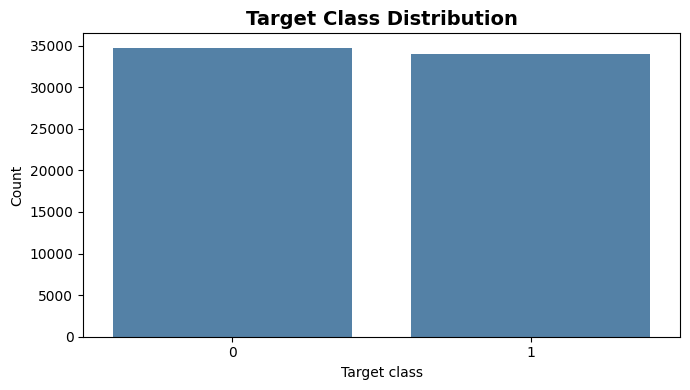

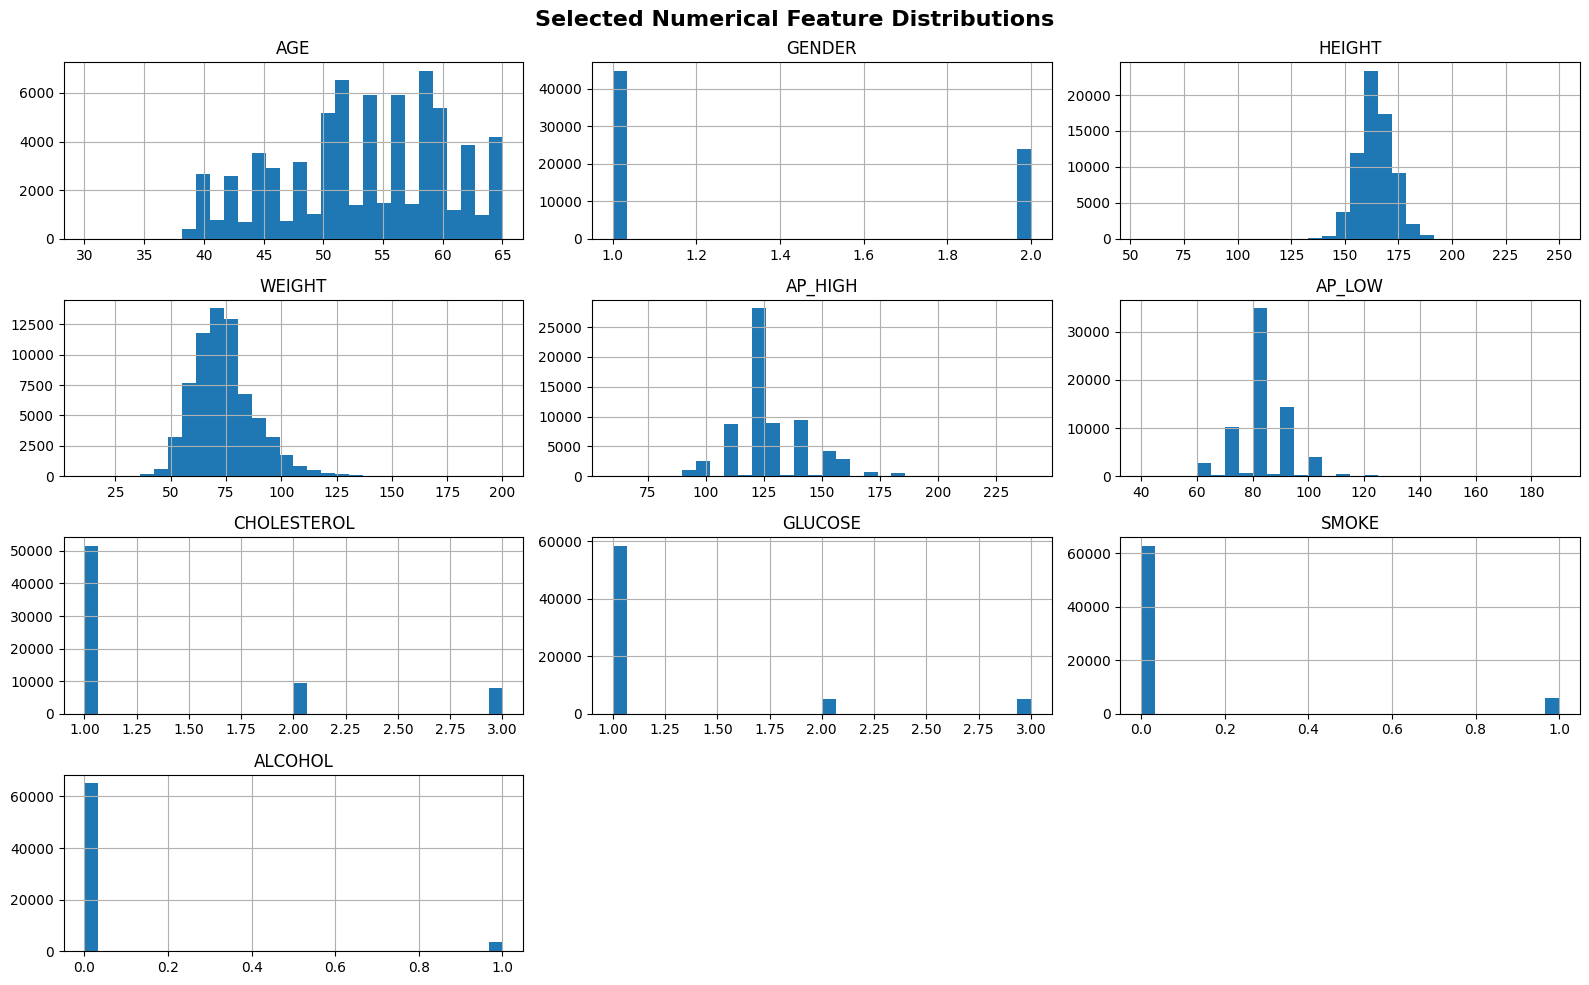

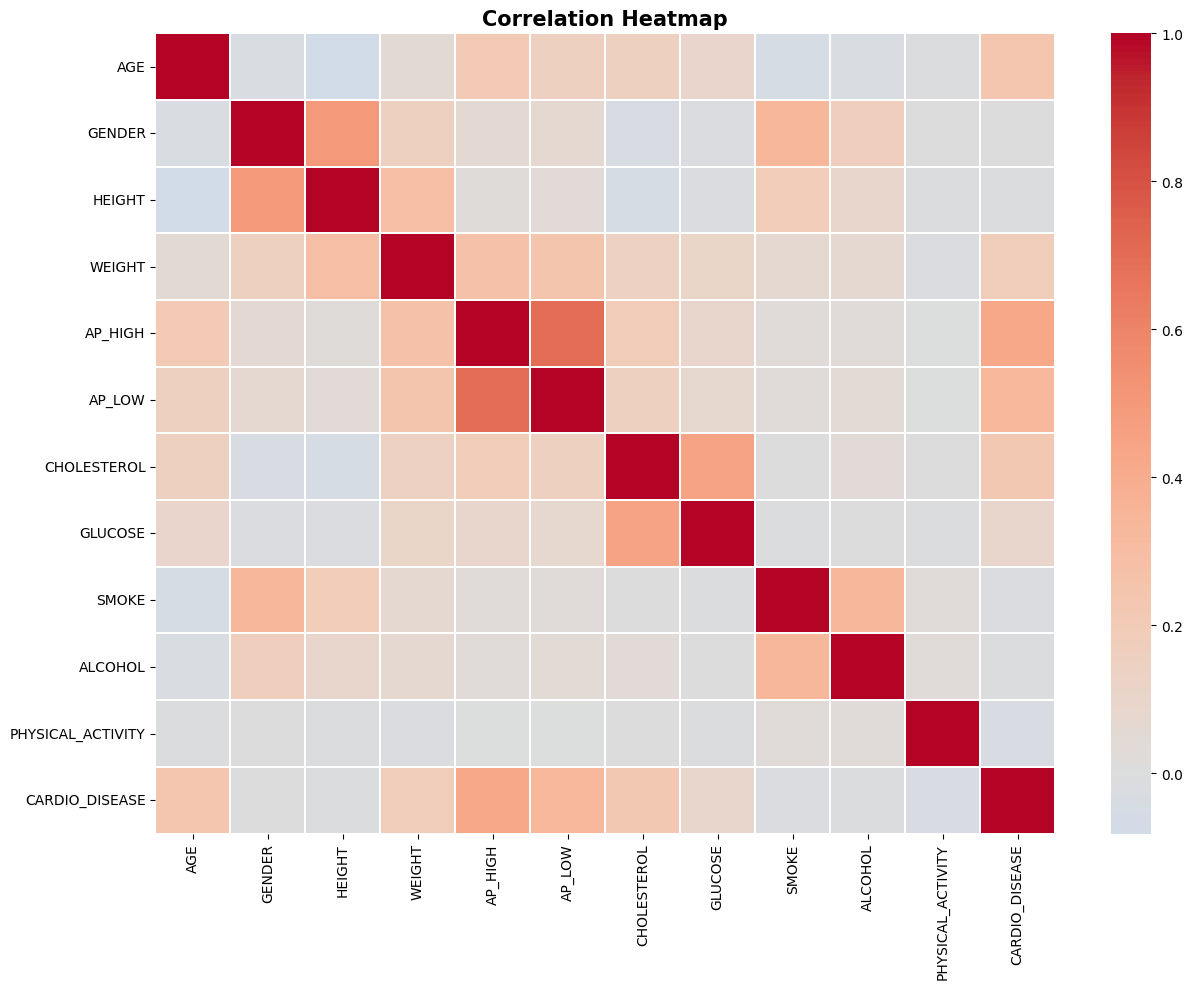

In [7]:
print("=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

plt.figure(figsize=(7, 4))
sns.countplot(x=TARGET_COLUMN_CLEAN, data=df, color="steelblue")
plt.title("Target Class Distribution", fontsize=14, weight="bold")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_target_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

num_cols_for_eda = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COLUMN_CLEAN in num_cols_for_eda:
    num_cols_for_eda.remove(TARGET_COLUMN_CLEAN)

if len(num_cols_for_eda) > 0:
    selected_hist_cols = num_cols_for_eda[: min(10, len(num_cols_for_eda))]
    df[selected_hist_cols].hist(figsize=(16, 10), bins=30)
    plt.suptitle("Selected Numerical Feature Distributions", fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_numerical_feature_distributions.png", dpi=220, bbox_inches="tight")
    plt.show()

numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 2:
    plt.figure(figsize=(13, 10))
    corr = numeric_df.corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
    plt.title("Correlation Heatmap", fontsize=15, weight="bold")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_correlation_heatmap.png", dpi=220, bbox_inches="tight")
    plt.show()

## 6. Clinical feature engineering
Possible engineered features:
- Age in years.
- Body Mass Index.
- Pulse pressure.
- Blood pressure ratio.
- Cardiometabolic risk indicators.

In [8]:
df_fe = df.copy()
created_features = []

def add_feature_safe(name, values):
    if name not in df_fe.columns:
        df_fe[name] = values
        created_features.append(name)

colset = set(df_fe.columns)

if "AGE" in colset:
    if pd.api.types.is_numeric_dtype(df_fe["AGE"]) and df_fe["AGE"].median() > 130:
        add_feature_safe("AGE_YEARS", df_fe["AGE"] / 365.25)
    else:
        add_feature_safe("AGE_YEARS", df_fe["AGE"])

if {"HEIGHT", "WEIGHT"}.issubset(colset):
    height_m = df_fe["HEIGHT"] / 100.0
    bmi = df_fe["WEIGHT"] / (height_m.replace(0, np.nan) ** 2)
    add_feature_safe("BMI", bmi.replace([np.inf, -np.inf], np.nan))

systolic_candidates = ["AP_HIGH", "SYSTOLIC", "SYSBP", "TRESTBPS", "RESTING_BPS", "RESTINGBP"]
diastolic_candidates = ["AP_LOW", "DIASTOLIC", "DIABP", "RESTING_DBP"]

systolic_col = next((c for c in systolic_candidates if c in colset), None)
diastolic_col = next((c for c in diastolic_candidates if c in colset), None)

if systolic_col and diastolic_col:
    pulse_pressure = df_fe[systolic_col] - df_fe[diastolic_col]
    bp_ratio = df_fe[systolic_col] / df_fe[diastolic_col].replace(0, np.nan)
    add_feature_safe("PULSE_PRESSURE", pulse_pressure.replace([np.inf, -np.inf], np.nan))
    add_feature_safe("BP_RATIO", bp_ratio.replace([np.inf, -np.inf], np.nan))

if {"AGE_YEARS", "BMI"}.issubset(set(df_fe.columns)):
    add_feature_safe("AGE_BMI_INTERACTION", df_fe["AGE_YEARS"] * df_fe["BMI"])

if "CHOLESTEROL" in colset and "AGE_YEARS" in df_fe.columns:
    add_feature_safe("AGE_CHOLESTEROL_INTERACTION", df_fe["AGE_YEARS"] * df_fe["CHOLESTEROL"])

print(f"Created {len(created_features)} engineered features:")
print(created_features if created_features else "No extra features were created because source columns were unavailable.")
display(df_fe.head())

Created 6 engineered features:
['AGE_YEARS', 'BMI', 'PULSE_PRESSURE', 'BP_RATIO', 'AGE_BMI_INTERACTION', 'AGE_CHOLESTEROL_INTERACTION']


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,AGE_YEARS,BMI,PULSE_PRESSURE,BP_RATIO,AGE_BMI_INTERACTION,AGE_CHOLESTEROL_INTERACTION
0,50,2,168,62,110,80,1,1,0,0,1,0,50,21.967120,30,1.375000,1098.356009,50
1,55,1,156,85,140,90,3,1,0,0,1,1,55,34.927679,50,1.555556,1921.022354,165
2,52,1,165,64,130,70,3,1,0,0,0,1,52,23.507805,60,1.857143,1222.405877,156
3,48,2,169,82,150,100,1,1,0,0,1,1,48,28.710479,50,1.500000,1378.103008,48
4,48,1,156,56,100,60,1,1,0,0,0,0,48,23.011177,40,1.666667,1104.536489,48


## 7. Train/test split and preprocessing

In [9]:
df_model = df_fe.copy()
df_model = df_model.dropna(subset=[TARGET_COLUMN_CLEAN]).reset_index(drop=True)

id_like_cols = [
    c for c in df_model.columns
    if c != TARGET_COLUMN_CLEAN and c in {"ID", "INDEX", "PATIENT_ID", "SUBJECT_ID", "ROW_ID"}
]
if id_like_cols:
    print(f"Dropping identifier-like columns: {id_like_cols}")
    df_model = df_model.drop(columns=id_like_cols)

X_raw = df_model.drop(columns=[TARGET_COLUMN_CLEAN])
y_raw = df_model[TARGET_COLUMN_CLEAN]

if pd.api.types.is_numeric_dtype(y_raw):
    unique_values = sorted(pd.Series(y_raw.dropna().unique()).tolist())
    if len(unique_values) > 2 and 0 in unique_values:
        print("Target has more than two numeric values. Converting to binary: 0 = no disease, >0 = disease.")
        y_clean = (y_raw.astype(float) > 0).astype(int)
    else:
        y_clean = y_raw.astype(int)
else:
    label_encoder_initial = LabelEncoder()
    y_clean = pd.Series(label_encoder_initial.fit_transform(y_raw.astype(str)), index=y_raw.index)

unique_target_values = sorted(pd.Series(y_clean).unique().tolist())
if len(unique_target_values) != 2:
    raise ValueError(f"This RL diagnostic notebook expects binary classification. Found classes: {unique_target_values}")

y = pd.Series(y_clean, name=TARGET_COLUMN_CLEAN).astype(int)
class_names = ["No CVD", "CVD"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=VALIDATION_SIZE, stratify=y_train, random_state=RANDOM_STATE
)

numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train_raw.columns if c not in numeric_features]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_val_processed = preprocessor.transform(X_val_raw)
X_test_processed = preprocessor.transform(X_test_raw)

try:
    processed_feature_names = preprocessor.get_feature_names_out()
    processed_feature_names = [str(f).replace("num__", "").replace("cat__", "") for f in processed_feature_names]
except Exception:
    processed_feature_names = [f"FEATURE_{i}" for i in range(X_train_processed.shape[1])]

X_train_processed = np.asarray(X_train_processed, dtype=np.float32)
X_val_processed = np.asarray(X_val_processed, dtype=np.float32)
X_test_processed = np.asarray(X_test_processed, dtype=np.float32)

print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")
print(f"Processed feature count: {len(processed_feature_names)}")
print(f"Numeric raw features: {len(numeric_features)}")
print(f"Categorical raw features: {len(categorical_features)}")

Train shape: (44020, 17)
Validation shape: (11006, 17)
Test shape: (13757, 17)
Processed feature count: 17
Numeric raw features: 17
Categorical raw features: 0


## 8. Feature selection for RL action-space control

Selected 17 features for RL:


,feature,importance
15,AGE_BMI_INTERACTION,0.127311
12,BMI,0.124524
3,WEIGHT,0.119418
2,HEIGHT,0.116228
4,AP_HIGH,0.113696
5,AP_LOW,0.067318
13,PULSE_PRESSURE,0.056396
16,AGE_CHOLESTEROL_INTERACTION,0.053309
11,AGE_YEARS,0.043670
0,AGE,0.042170


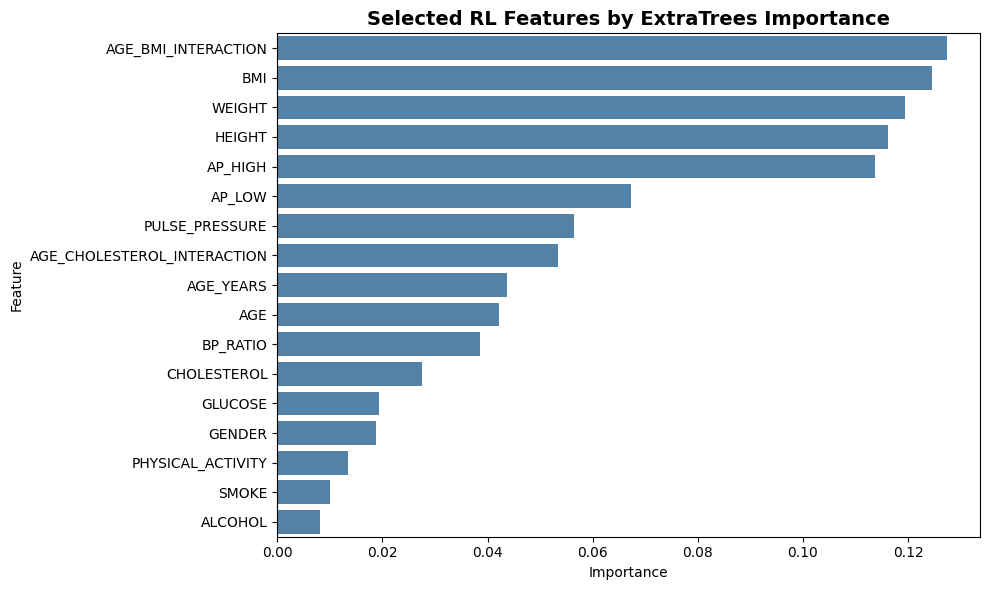

In [11]:
selector_model = ExtraTreesClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

selector_model.fit(X_train_processed, y_train)
selector_importances = selector_model.feature_importances_

max_features_for_rl = min(MAX_RL_FEATURES, X_train_processed.shape[1])
selected_indices = np.argsort(selector_importances)[::-1][:max_features_for_rl]
selected_indices = np.sort(selected_indices)

feature_names_rl = [processed_feature_names[i] for i in selected_indices]

X_train_rl = X_train_processed[:, selected_indices]
X_val_rl = X_val_processed[:, selected_indices]
X_test_rl = X_test_processed[:, selected_indices]

importance_table = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": selector_importances,
}).sort_values("importance", ascending=False)

print(f"Selected {len(feature_names_rl)} features for RL:")
display(importance_table.head(len(feature_names_rl)))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_table.head(len(feature_names_rl)), x="importance", y="feature", color="steelblue")
plt.title("Selected RL Features by ExtraTrees Importance", fontsize=14, weight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_selected_rl_features.png", dpi=220, bbox_inches="tight")
plt.show()

## 9. Supervised baseline for comparison

,model,accuracy,precision,recall,f1,roc_auc,average_precision
1,Random Forest,0.717162,0.722163,0.696387,0.709041,0.779280,0.758565
0,Logistic Regression,0.722323,0.736767,0.682873,0.708797,0.786656,0.763800
2,Extra Trees,0.688159,0.682042,0.692861,0.687409,0.735630,0.685393


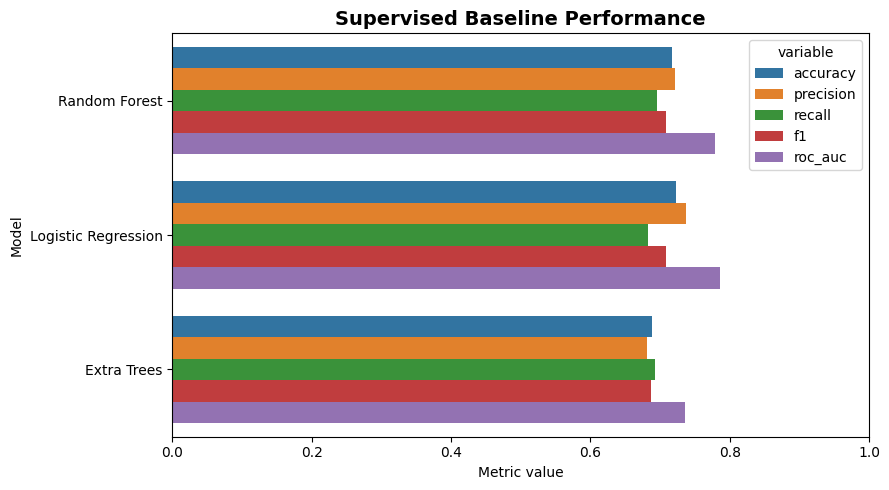

In [12]:
def compute_binary_metrics(y_true, y_pred, y_score=None, prefix=""):
    metrics = {
        f"{prefix}accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}precision": precision_score(y_true, y_pred, zero_division=0),
        f"{prefix}recall": recall_score(y_true, y_pred, zero_division=0),
        f"{prefix}f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        metrics[f"{prefix}roc_auc"] = roc_auc_score(y_true, y_score)
        metrics[f"{prefix}average_precision"] = average_precision_score(y_true, y_score)
    return metrics

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

baseline_rows = []
trained_baselines = {}

for name, model in baseline_models.items():
    model.fit(X_train_rl, y_train)
    pred = model.predict(X_test_rl)
    score = model.predict_proba(X_test_rl)[:, 1] if hasattr(model, "predict_proba") else pred
    metrics = compute_binary_metrics(y_test, pred, score)
    baseline_rows.append({"model": name, **metrics})
    trained_baselines[name] = model

baseline_results = pd.DataFrame(baseline_rows).sort_values("f1", ascending=False)
display(baseline_results)
baseline_results.to_csv(OUTPUT_DIR / "supervised_baseline_metrics.csv", index=False)

plt.figure(figsize=(9, 5))
baseline_melted = baseline_results.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"])
sns.barplot(data=baseline_melted, x="value", y="model", hue="variable")
plt.title("Supervised Baseline Performance", fontsize=14, weight="bold")
plt.xlabel("Metric value")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_supervised_baseline_metrics.png", dpi=220, bbox_inches="tight")
plt.show()

## 10. Clinical RL environment

The environment implements an interpretable feature-acquisition process.

### State
For each patient, the agent observes:
- current known feature values,
- a binary mask indicating which features are known,
- the fraction of the feature budget already used.

### Actions
The agent can:
- acquire one unknown feature,
- diagnose `No CVD`,
- diagnose `CVD`.

### Rewards
The reward function is clinically asymmetric:
- True positive: high positive reward.
- True negative: moderate positive reward.
- False positive: moderate penalty.
- False negative: strongest penalty.
- Each acquired feature has a small cost, encouraging efficient explanations.

In [13]:
class CardiovascularFeatureAcquisitionEnv:
    def __init__(
        self,
        X,
        y,
        feature_names,
        max_steps=8,
        feature_cost=0.03,
        repeat_feature_penalty=0.10,
        no_diagnosis_penalty=1.00,
        reward_tp=2.00,
        reward_tn=1.25,
        reward_fp=-1.25,
        reward_fn=-3.00,
        seed=42,
    ):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)
        self.feature_names = list(feature_names)
        self.n_features = self.X.shape[1]
        self.max_steps = min(max_steps, self.n_features)
        self.feature_cost = feature_cost
        self.repeat_feature_penalty = repeat_feature_penalty
        self.no_diagnosis_penalty = no_diagnosis_penalty
        self.reward_tp = reward_tp
        self.reward_tn = reward_tn
        self.reward_fp = reward_fp
        self.reward_fn = reward_fn
        self.rng = np.random.default_rng(seed)

        self.action_diagnose_no = self.n_features
        self.action_diagnose_yes = self.n_features + 1
        self.n_actions = self.n_features + 2
        self.state_dim = self.n_features * 2 + 1
        self.reset()

    def reset(self, index=None):
        self.index = int(self.rng.integers(0, len(self.X))) if index is None else int(index)
        self.patient = self.X[self.index].copy()
        self.true_label = int(self.y[self.index])
        self.observed_values = np.zeros(self.n_features, dtype=np.float32)
        self.observed_mask = np.zeros(self.n_features, dtype=np.float32)
        self.steps = 0
        self.done = False
        self.acquired_features = []
        self.reward_components = {
            "feature_cost": 0.0,
            "diagnosis_reward": 0.0,
            "repeat_penalty": 0.0,
            "no_diagnosis_penalty": 0.0,
        }
        return self._get_state()

    def _get_state(self):
        step_fraction = np.array([self.steps / max(1, self.max_steps)], dtype=np.float32)
        return np.concatenate([self.observed_values, self.observed_mask, step_fraction]).astype(np.float32)

    def valid_action_mask(self):
        mask = np.zeros(self.n_actions, dtype=bool)
        mask[: self.n_features] = self.observed_mask < 0.5
        mask[self.action_diagnose_no] = True
        mask[self.action_diagnose_yes] = True
        return mask

    def action_name(self, action):
        if action < self.n_features:
            return f"Acquire: {self.feature_names[action]}"
        if action == self.action_diagnose_no:
            return "Diagnose: No CVD"
        if action == self.action_diagnose_yes:
            return "Diagnose: CVD"
        return f"Unknown action {action}"

    def _diagnosis_reward(self, predicted_label):
        if predicted_label == 1 and self.true_label == 1:
            return self.reward_tp, "TP"
        if predicted_label == 0 and self.true_label == 0:
            return self.reward_tn, "TN"
        if predicted_label == 1 and self.true_label == 0:
            return self.reward_fp, "FP"
        return self.reward_fn, "FN"

    def step(self, action):
        if self.done:
            raise RuntimeError("Episode already finished. Call reset().")

        info = {
            "action_name": self.action_name(action),
            "prediction": None,
            "outcome": None,
            "acquired_feature": None,
            "forced_stop": False,
        }

        if action < self.n_features:
            if self.observed_mask[action] >= 0.5:
                reward = -self.repeat_feature_penalty
                self.reward_components["repeat_penalty"] += reward
            else:
                self.observed_values[action] = self.patient[action]
                self.observed_mask[action] = 1.0
                self.acquired_features.append(self.feature_names[action])
                reward = -self.feature_cost
                self.reward_components["feature_cost"] += reward
                info["acquired_feature"] = self.feature_names[action]

            self.steps += 1
            if self.steps >= self.max_steps:
                self.done = True
                reward -= self.no_diagnosis_penalty
                self.reward_components["no_diagnosis_penalty"] -= self.no_diagnosis_penalty
                info["forced_stop"] = True
            return self._get_state(), float(reward), self.done, info

        if action in [self.action_diagnose_no, self.action_diagnose_yes]:
            predicted_label = 0 if action == self.action_diagnose_no else 1
            reward, outcome = self._diagnosis_reward(predicted_label)
            self.reward_components["diagnosis_reward"] += reward
            self.done = True
            info["prediction"] = predicted_label
            info["outcome"] = outcome
            return self._get_state(), float(reward), self.done, info

        raise ValueError(f"Invalid action: {action}")

train_env = CardiovascularFeatureAcquisitionEnv(
    X_train_rl,
    y_train.values,
    feature_names_rl,
    max_steps=MAX_STEPS,
    feature_cost=FEATURE_COST,
    repeat_feature_penalty=REPEAT_FEATURE_PENALTY,
    no_diagnosis_penalty=NO_DIAGNOSIS_PENALTY,
    reward_tp=REWARD_TRUE_POSITIVE,
    reward_tn=REWARD_TRUE_NEGATIVE,
    reward_fp=REWARD_FALSE_POSITIVE,
    reward_fn=REWARD_FALSE_NEGATIVE,
    seed=RANDOM_STATE,
)

print(f"State dimension: {train_env.state_dim}")
print(f"Action count: {train_env.n_actions}")
print(f"Diagnosis actions: {train_env.action_diagnose_no} = No CVD, {train_env.action_diagnose_yes} = CVD")
print(f"Maximum feature acquisitions before forced stop: {train_env.max_steps}")

State dimension: 35
Action count: 19
Diagnosis actions: 17 = No CVD, 18 = CVD
Maximum feature acquisitions before forced stop: 8


## 11. DQN model and replay buffer

In [14]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=160, dropout=0.05):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, action_dim),
        )

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=30000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done, next_valid_mask):
        self.buffer.append((
            np.asarray(state, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_state, dtype=np.float32),
            bool(done),
            np.asarray(next_valid_mask, dtype=bool),
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones, next_valid_masks = zip(*batch)
        return (
            torch.tensor(np.asarray(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.long, device=DEVICE),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE),
            torch.tensor(np.asarray(next_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE),
            torch.tensor(np.asarray(next_valid_masks), dtype=torch.bool, device=DEVICE),
        )

    def __len__(self):
        return len(self.buffer)

policy_net = DQN(train_env.state_dim, train_env.n_actions).to(DEVICE)
target_net = DQN(train_env.state_dim, train_env.n_actions).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.AdamW(policy_net.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
replay_buffer = ReplayBuffer(capacity=REPLAY_CAPACITY)

def select_action(state, valid_mask, epsilon):
    valid_indices = np.where(valid_mask)[0]
    if np.random.rand() < epsilon:
        return int(np.random.choice(valid_indices))

    policy_net.eval()
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        q_values = policy_net(state_t).cpu().numpy()[0]

    q_values[~valid_mask] = -1e9
    return int(np.argmax(q_values))

def optimize_dqn():
    if len(replay_buffer) < BATCH_SIZE:
        return None

    states, actions, rewards, next_states, dones, next_valid_masks = replay_buffer.sample(BATCH_SIZE)

    policy_net.train()
    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q_values = target_net(next_states)
        next_q_values = next_q_values.masked_fill(~next_valid_masks, -1e9)
        max_next_q = next_q_values.max(dim=1).values
        targets = rewards + GAMMA * (1.0 - dones) * max_next_q

    loss = F.smooth_l1_loss(q_values, targets)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=5.0)
    optimizer.step()

    return float(loss.item())

print(policy_net)

DQN(
  (net): Sequential(
    (0): Linear(in_features=35, out_features=160, bias=True)
    (1): ReLU()
    (2): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=160, out_features=160, bias=True)
    (5): ReLU()
    (6): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=160, out_features=80, bias=True)
    (9): ReLU()
    (10): Linear(in_features=80, out_features=19, bias=True)
  )
)


## 12. Training the interpretable DQN diagnostic policy

Episode     1/8000 | epsilon=1.000 | val_f1=0.5918 | val_recall=0.8610 | val_auc=0.4491 | mean_features=7.97
Episode  1000/8000 | epsilon=0.670 | val_f1=0.6385 | val_recall=0.9531 | val_auc=0.6338 | mean_features=6.36
Episode  2000/8000 | epsilon=0.449 | val_f1=0.6347 | val_recall=0.8845 | val_auc=0.6377 | mean_features=5.89
Episode  3000/8000 | epsilon=0.301 | val_f1=0.6567 | val_recall=0.9477 | val_auc=0.5237 | mean_features=4.17
Episode  4000/8000 | epsilon=0.202 | val_f1=0.6530 | val_recall=0.8069 | val_auc=0.6831 | mean_features=6.09
Episode  5000/8000 | epsilon=0.135 | val_f1=0.6618 | val_recall=0.8231 | val_auc=0.6709 | mean_features=6.45
Episode  6000/8000 | epsilon=0.091 | val_f1=0.6398 | val_recall=0.7455 | val_auc=0.6637 | mean_features=4.74
Episode  7000/8000 | epsilon=0.061 | val_f1=0.6830 | val_recall=0.8303 | val_auc=0.7135 | mean_features=5.72
Episode  8000/8000 | epsilon=0.050 | val_f1=0.6877 | val_recall=0.8051 | val_auc=0.7104 | mean_features=5.47

Training complete 

,episode,epsilon,latest_loss,accuracy,precision,recall,f1,roc_auc,average_precision,mean_reward,mean_features_used,forced_prediction_rate
4,4000,0.201832,0.064087,0.604167,0.548466,0.806859,0.653031,0.683090,0.627926,0.157008,6.085833,0.044167
5,5000,0.135281,0.068071,0.611667,0.553398,0.823105,0.661829,0.670864,0.607061,0.126842,6.452500,0.100833
6,6000,0.090674,0.066230,0.612500,0.560380,0.745487,0.639814,0.663690,0.622875,0.107333,4.741667,0.084167
7,7000,0.060776,0.064322,0.644167,0.580076,0.830325,0.682999,0.713488,0.632798,0.299917,5.725000,0.039167
8,8000,0.050000,0.061462,0.662500,0.600269,0.805054,0.687741,0.710449,0.629476,0.312492,5.472500,0.050833


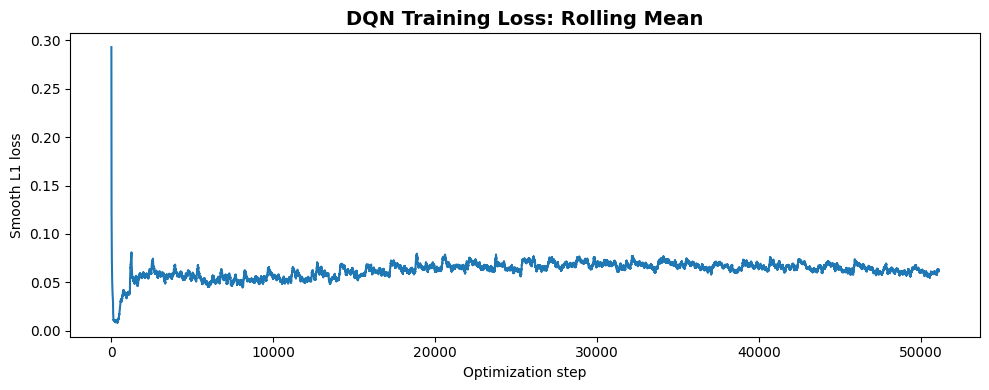

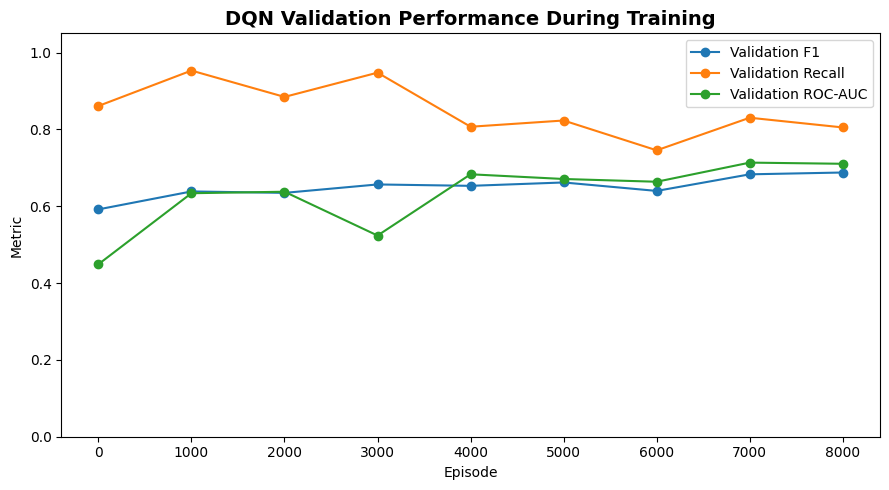

In [15]:
def evaluate_policy_array(X_array, y_array, max_patients=None):
    eval_env = CardiovascularFeatureAcquisitionEnv(
        X_array,
        y_array,
        feature_names_rl,
        max_steps=MAX_STEPS,
        feature_cost=FEATURE_COST,
        repeat_feature_penalty=REPEAT_FEATURE_PENALTY,
        no_diagnosis_penalty=NO_DIAGNOSIS_PENALTY,
        reward_tp=REWARD_TRUE_POSITIVE,
        reward_tn=REWARD_TRUE_NEGATIVE,
        reward_fp=REWARD_FALSE_POSITIVE,
        reward_fn=REWARD_FALSE_NEGATIVE,
        seed=RANDOM_STATE + 999,
    )

    n = len(X_array) if max_patients is None else min(max_patients, len(X_array))
    records = []
    trajectories = []
    policy_net.eval()

    for idx in range(n):
        state = eval_env.reset(index=idx)
        total_reward = 0.0
        action_sequence = []
        feature_sequence = []
        forced_prediction = False
        prediction = None
        outcome = None
        final_q = None

        for step_id in range(MAX_STEPS + 2):
            valid_mask = eval_env.valid_action_mask()
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                q_values = policy_net(state_t).cpu().numpy()[0]
            q_masked = q_values.copy()
            q_masked[~valid_mask] = -1e9
            action = int(np.argmax(q_masked))

            action_sequence.append(eval_env.action_name(action))
            next_state, reward, done, info = eval_env.step(action)
            total_reward += reward

            if info.get("acquired_feature") is not None:
                feature_sequence.append(info["acquired_feature"])
            if info.get("prediction") is not None:
                prediction = int(info["prediction"])
                outcome = info["outcome"]

            state = next_state
            final_q = q_values

            if done:
                break

        if prediction is None:
            forced_prediction = True
            with torch.no_grad():
                state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                final_q = policy_net(state_t).cpu().numpy()[0]
            diag_q = final_q[[eval_env.action_diagnose_no, eval_env.action_diagnose_yes]]
            prediction = int(np.argmax(diag_q))
            forced_reward, outcome = eval_env._diagnosis_reward(prediction)
            total_reward += forced_reward

        diag_q = final_q[[eval_env.action_diagnose_no, eval_env.action_diagnose_yes]]
        exp_diag_q = np.exp(diag_q - np.max(diag_q))
        diag_proba = exp_diag_q / diag_q.size if exp_diag_q.sum() == 0 else exp_diag_q / exp_diag_q.sum()
        risk_score = float(diag_proba[1])

        records.append({
            "index": idx,
            "true_label": int(y_array[idx]),
            "prediction": int(prediction),
            "risk_score": risk_score,
            "total_reward": float(total_reward),
            "outcome": outcome,
            "n_features_used": len(feature_sequence),
            "forced_prediction": forced_prediction,
            "features_used": " -> ".join(feature_sequence),
            "actions": " -> ".join(action_sequence),
            "feature_cost_component": float(eval_env.reward_components["feature_cost"]),
            "diagnosis_reward_component": float(eval_env.reward_components["diagnosis_reward"]),
            "repeat_penalty_component": float(eval_env.reward_components["repeat_penalty"]),
            "no_diagnosis_penalty_component": float(eval_env.reward_components["no_diagnosis_penalty"]),
        })

        trajectories.append({
            "index": idx,
            "true_label": int(y_array[idx]),
            "prediction": int(prediction),
            "risk_score": risk_score,
            "feature_sequence": feature_sequence,
            "action_sequence": action_sequence,
            "reward_components": eval_env.reward_components.copy(),
        })

    eval_df = pd.DataFrame(records)
    metrics = compute_binary_metrics(
        eval_df["true_label"].values,
        eval_df["prediction"].values,
        eval_df["risk_score"].values,
    )
    metrics["mean_reward"] = eval_df["total_reward"].mean()
    metrics["mean_features_used"] = eval_df["n_features_used"].mean()
    metrics["forced_prediction_rate"] = eval_df["forced_prediction"].mean()

    return eval_df, trajectories, metrics

training_log = []
epsilon = EPS_START
best_val_f1 = -np.inf
best_state_dict = None
losses = []

start_time = time.time()

for episode in range(1, DQN_EPISODES + 1):
    state = train_env.reset()

    for step in range(MAX_STEPS + 2):
        valid_mask = train_env.valid_action_mask()
        action = select_action(state, valid_mask, epsilon)

        next_state, reward, done, info = train_env.step(action)
        next_valid_mask = train_env.valid_action_mask() if not done else np.zeros(train_env.n_actions, dtype=bool)

        replay_buffer.push(state, action, reward, next_state, done, next_valid_mask)

        loss_value = optimize_dqn()
        if loss_value is not None:
            losses.append(loss_value)

        state = next_state

        if done:
            break

    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    if episode % TARGET_UPDATE_EVERY == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % EVAL_EVERY == 0 or episode == 1:
        val_eval_df, _, val_metrics = evaluate_policy_array(
            X_val_rl,
            y_val.values,
            max_patients=min(1200, len(X_val_rl)),
        )

        log_row = {
            "episode": episode,
            "epsilon": epsilon,
            "latest_loss": float(np.mean(losses[-100:])) if len(losses) > 0 else np.nan,
            **val_metrics,
        }
        training_log.append(log_row)

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in policy_net.state_dict().items()}

        print(
            f"Episode {episode:>5}/{DQN_EPISODES} | "
            f"epsilon={epsilon:.3f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_recall={val_metrics['recall']:.4f} | "
            f"val_auc={val_metrics.get('roc_auc', np.nan):.4f} | "
            f"mean_features={val_metrics['mean_features_used']:.2f}"
        )

if best_state_dict is not None:
    policy_net.load_state_dict(best_state_dict)
    target_net.load_state_dict(best_state_dict)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.2f} minutes.")
print(f"Best validation F1: {best_val_f1:.4f}")

training_log_df = pd.DataFrame(training_log)
training_log_df.to_csv(OUTPUT_DIR / "dqn_training_log.csv", index=False)
display(training_log_df.tail())

if len(losses) > 0:
    plt.figure(figsize=(10, 4))
    pd.Series(losses).rolling(100, min_periods=1).mean().plot()
    plt.title("DQN Training Loss: Rolling Mean", fontsize=14, weight="bold")
    plt.xlabel("Optimization step")
    plt.ylabel("Smooth L1 loss")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_dqn_training_loss.png", dpi=220, bbox_inches="tight")
    plt.show()

if len(training_log_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(training_log_df["episode"], training_log_df["f1"], marker="o", label="Validation F1")
    plt.plot(training_log_df["episode"], training_log_df["recall"], marker="o", label="Validation Recall")
    if "roc_auc" in training_log_df.columns:
        plt.plot(training_log_df["episode"], training_log_df["roc_auc"], marker="o", label="Validation ROC-AUC")
    plt.title("DQN Validation Performance During Training", fontsize=14, weight="bold")
    plt.xlabel("Episode")
    plt.ylabel("Metric")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "07_dqn_validation_curve.png", dpi=220, bbox_inches="tight")
    plt.show()

## 13. Final RL model evaluation

Final RL/DQN test metrics:


,value
accuracy,0.673911
precision,0.635000
recall,0.802145
f1,0.708853
roc_auc,0.705652
average_precision,0.648595
mean_reward,0.356345
mean_features_used,5.314894
forced_prediction_rate,0.045359



Classification report:
              precision    recall  f1-score   support

      No CVD       0.74      0.55      0.63      6949
         CVD       0.64      0.80      0.71      6808

    accuracy                           0.67     13757
   macro avg       0.69      0.68      0.67     13757
weighted avg       0.69      0.67      0.67     13757



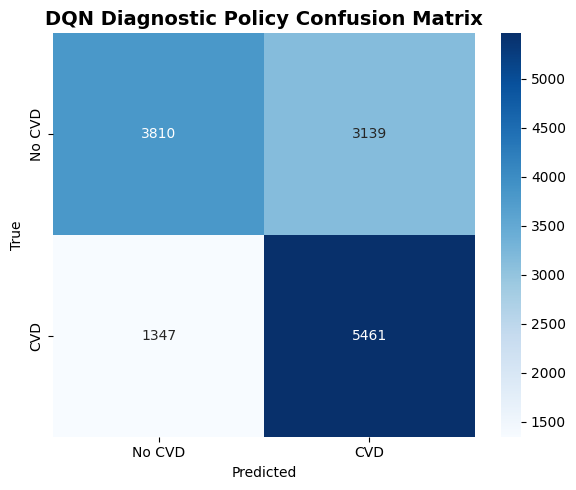

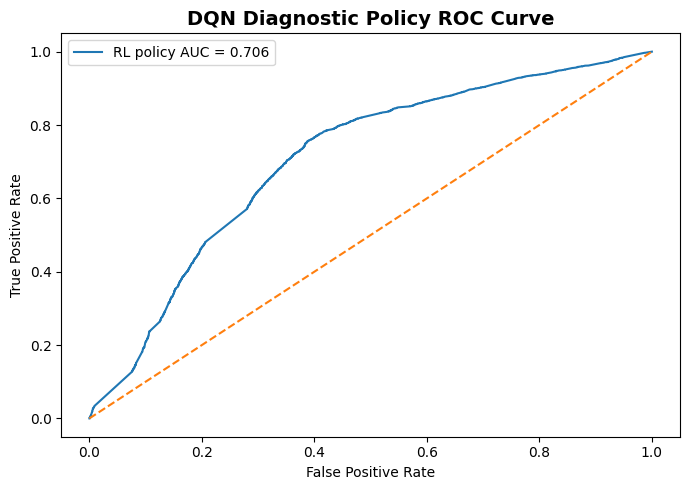

,model,accuracy,precision,recall,f1,roc_auc,average_precision,mean_reward,mean_features_used,forced_prediction_rate
0,Random Forest,0.717162,0.722163,0.696387,0.709041,0.779280,0.758565,NaN,NaN,NaN
1,Logistic Regression,0.722323,0.736767,0.682873,0.708797,0.786656,0.763800,NaN,NaN,NaN
2,Extra Trees,0.688159,0.682042,0.692861,0.687409,0.735630,0.685393,NaN,NaN,NaN
3,Glanois-style Interpretable DQN,0.673911,0.635000,0.802145,0.708853,0.705652,0.648595,0.356345,5.314894,0.045359


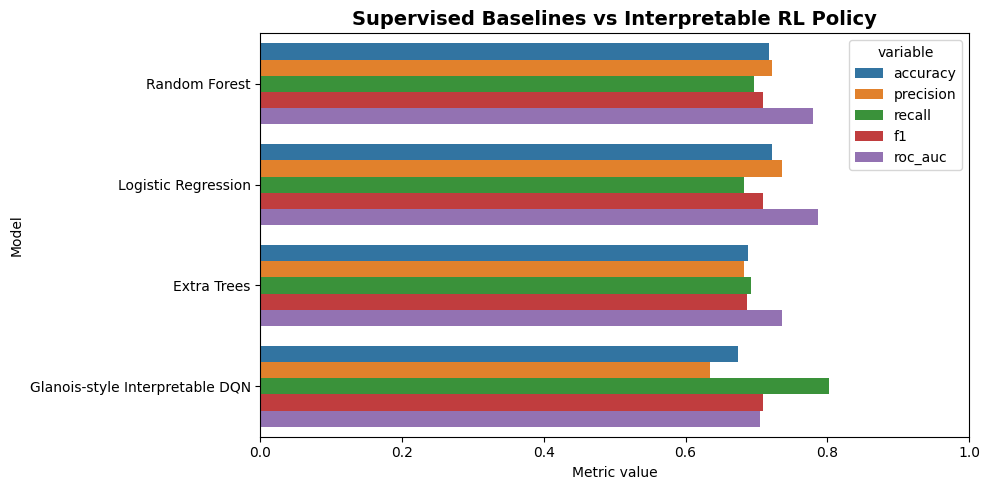

In [16]:
test_eval_df, test_trajectories, rl_test_metrics = evaluate_policy_array(
    X_test_rl,
    y_test.values,
    max_patients=None,
)

print("Final RL/DQN test metrics:")
display(pd.DataFrame([rl_test_metrics]).T.rename(columns={0: "value"}))
test_eval_df.to_csv(OUTPUT_DIR / "dqn_test_patient_level_predictions.csv", index=False)

print("\nClassification report:")
print(classification_report(test_eval_df["true_label"], test_eval_df["prediction"], target_names=class_names, zero_division=0))

cm = confusion_matrix(test_eval_df["true_label"], test_eval_df["prediction"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("DQN Diagnostic Policy Confusion Matrix", fontsize=14, weight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_dqn_confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

if len(np.unique(test_eval_df["true_label"])) == 2:
    fpr, tpr, _ = roc_curve(test_eval_df["true_label"], test_eval_df["risk_score"])
    precision_curve, recall_curve, _ = precision_recall_curve(test_eval_df["true_label"], test_eval_df["risk_score"])

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"RL policy AUC = {rl_test_metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("DQN Diagnostic Policy ROC Curve", fontsize=14, weight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "09_dqn_roc_curve.png", dpi=220, bbox_inches="tight")
    plt.show()

comparison_rows = baseline_results.copy()
comparison_rows = pd.concat([
    comparison_rows,
    pd.DataFrame([{"model": "Glanois-style Interpretable DQN", **rl_test_metrics}])
], ignore_index=True)

display(comparison_rows)
comparison_rows.to_csv(OUTPUT_DIR / "model_comparison_supervised_vs_rl.csv", index=False)

plt.figure(figsize=(10, 5))
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = comparison_rows.melt(id_vars="model", value_vars=[c for c in metric_cols if c in comparison_rows.columns])
sns.barplot(data=plot_df, x="value", y="model", hue="variable")
plt.title("Supervised Baselines vs Interpretable RL Policy", fontsize=14, weight="bold")
plt.xlabel("Metric value")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "11_supervised_vs_rl_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

# Part B — Interpretability and Explainability

The next sections are the most important part of this notebook. They are designed to match the Glanois interpretability perspective by explaining:

- **Inputs:** which features are exposed and requested.
- **Transition/reward behavior:** how rewards change with diagnostic outcomes and feature costs.
- **Decision-making:** how the policy selects actions and diagnoses.
- **Post-hoc explanations:** SHAP, LIME, gradients, occlusion, counterfactuals, and distilled transparent policies.

## 14. Intrinsic interpretability: feature acquisition frequency

,feature,overall_count,overall_rate,positive_count,positive_rate,negative_count,negative_rate
0,AGE,13757,1.000000,6808,0.494875,6949,0.505125
11,AGE_YEARS,8335,0.605873,3649,0.265247,4686,0.340627
4,AP_HIGH,6084,0.442248,2772,0.201497,3312,0.240750
13,PULSE_PRESSURE,5960,0.433234,2489,0.180926,3471,0.252308
9,ALCOHOL,5744,0.417533,2320,0.168641,3424,0.248891
5,AP_LOW,4371,0.317729,2074,0.150760,2297,0.166970
15,AGE_BMI_INTERACTION,4282,0.311260,2625,0.190812,1657,0.120448
8,SMOKE,3792,0.275641,1737,0.126263,2055,0.149378
2,HEIGHT,3417,0.248383,2184,0.158756,1233,0.089627
14,BP_RATIO,3104,0.225631,1350,0.098132,1754,0.127499


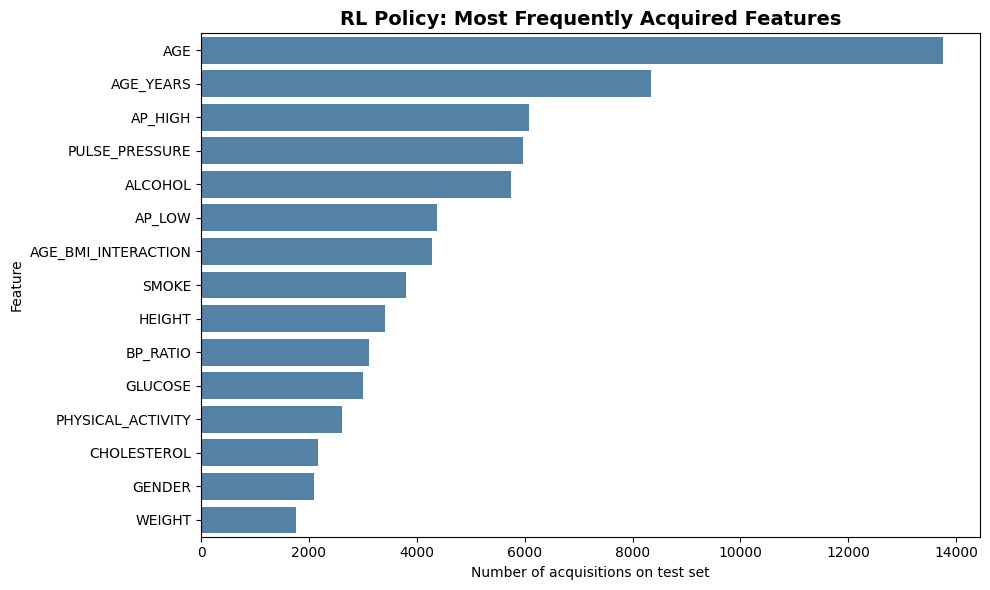

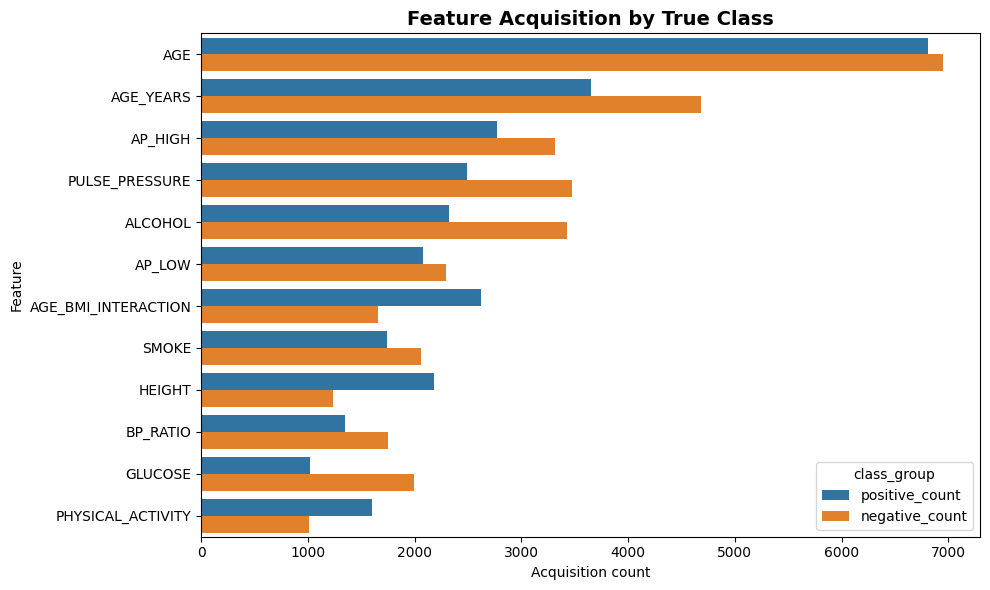

In [17]:
all_acquired_features = []
positive_acquired_features = []
negative_acquired_features = []

for traj in test_trajectories:
    all_acquired_features.extend(traj["feature_sequence"])
    if traj["true_label"] == 1:
        positive_acquired_features.extend(traj["feature_sequence"])
    else:
        negative_acquired_features.extend(traj["feature_sequence"])

def frequency_table(features, label):
    counts = Counter(features)
    table = pd.DataFrame({
        "feature": feature_names_rl,
        f"{label}_count": [counts.get(f, 0) for f in feature_names_rl],
    })
    table[f"{label}_rate"] = table[f"{label}_count"] / max(1, len(test_trajectories))
    return table

freq_all = frequency_table(all_acquired_features, "overall")
freq_pos = frequency_table(positive_acquired_features, "positive")
freq_neg = frequency_table(negative_acquired_features, "negative")

feature_acquisition_df = freq_all.merge(freq_pos, on="feature").merge(freq_neg, on="feature")
feature_acquisition_df = feature_acquisition_df.sort_values("overall_count", ascending=False)
display(feature_acquisition_df)
feature_acquisition_df.to_csv(OUTPUT_DIR / "xai_feature_acquisition_frequency.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_acquisition_df.head(15), x="overall_count", y="feature", color="steelblue")
plt.title("RL Policy: Most Frequently Acquired Features", fontsize=14, weight="bold")
plt.xlabel("Number of acquisitions on test set")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "12_feature_acquisition_frequency.png", dpi=220, bbox_inches="tight")
plt.show()

class_freq_plot = feature_acquisition_df.head(12)[["feature", "positive_count", "negative_count"]].melt(
    id_vars="feature", var_name="class_group", value_name="count"
)
plt.figure(figsize=(10, 6))
sns.barplot(data=class_freq_plot, x="count", y="feature", hue="class_group")
plt.title("Feature Acquisition by True Class", fontsize=14, weight="bold")
plt.xlabel("Acquisition count")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "13_feature_acquisition_by_class.png", dpi=220, bbox_inches="tight")
plt.show()

## 15. Patient-level decision trajectories

In [18]:
trajectory_examples = test_eval_df.copy()
priority_outcomes = ["TP", "FN", "FP", "TN"]
selected_example_indices = []

for outcome in priority_outcomes:
    matching = trajectory_examples[trajectory_examples["outcome"] == outcome]
    if len(matching) > 0:
        selected_example_indices.append(int(matching.iloc[0]["index"]))

selected_example_indices = selected_example_indices[:8]

rows = []
for idx in selected_example_indices:
    traj = test_trajectories[idx]
    rows.append({
        "patient_index": idx,
        "true_label": traj["true_label"],
        "prediction": traj["prediction"],
        "risk_score": round(traj["risk_score"], 4),
        "feature_sequence": " -> ".join(traj["feature_sequence"]),
        "action_sequence": " -> ".join(traj["action_sequence"]),
        "reward_components": traj["reward_components"],
    })

decision_path_df = pd.DataFrame(rows)
display(decision_path_df)
decision_path_df.to_csv(OUTPUT_DIR / "xai_patient_decision_trajectories.csv", index=False)

for row in rows:
    print("=" * 100)
    print(f"Patient #{row['patient_index']} | True={class_names[row['true_label']]} | Predicted={class_names[row['prediction']]} | Risk={row['risk_score']}")
    print("Feature acquisition path:")
    print(row["feature_sequence"] if row["feature_sequence"] else "No features acquired before diagnosis.")
    print("\nFull action path:")
    print(row["action_sequence"])
    print("\nReward components:")
    print(row["reward_components"])

,patient_index,true_label,prediction,risk_score,feature_sequence,action_sequence,reward_components
0,1,1,1,0.9940,AGE -> AGE_YEARS -> AP_LOW -> SMOKE -> BMI -> ...,Acquire: AGE -> Acquire: AGE_YEARS -> Acquire:...,"{'feature_cost': -0.21, 'diagnosis_reward': 2...."
1,6,1,0,0.0554,AGE -> AGE_YEARS -> PULSE_PRESSURE -> AP_HIGH ...,Acquire: AGE -> Acquire: AGE_YEARS -> Acquire:...,"{'feature_cost': -0.15, 'diagnosis_reward': -3..."
2,0,0,1,0.7753,AGE -> HEIGHT -> AGE_BMI_INTERACTION -> PHYSIC...,Acquire: AGE -> Acquire: HEIGHT -> Acquire: AG...,"{'feature_cost': -0.18, 'diagnosis_reward': -1..."
3,16,0,0,0.1177,AGE -> AGE_YEARS -> ALCOHOL -> PULSE_PRESSURE ...,Acquire: AGE -> Acquire: AGE_YEARS -> Acquire:...,"{'feature_cost': -0.18, 'diagnosis_reward': 1...."


Patient #1 | True=CVD | Predicted=CVD | Risk=0.994
Feature acquisition path:
AGE -> AGE_YEARS -> AP_LOW -> SMOKE -> BMI -> PULSE_PRESSURE -> AGE_BMI_INTERACTION

Full action path:
Acquire: AGE -> Acquire: AGE_YEARS -> Acquire: AP_LOW -> Acquire: SMOKE -> Acquire: BMI -> Acquire: PULSE_PRESSURE -> Acquire: AGE_BMI_INTERACTION -> Diagnose: CVD

Reward components:
{'feature_cost': -0.21, 'diagnosis_reward': 2.0, 'repeat_penalty': 0.0, 'no_diagnosis_penalty': 0.0}
Patient #6 | True=CVD | Predicted=No CVD | Risk=0.0554
Feature acquisition path:
AGE -> AGE_YEARS -> PULSE_PRESSURE -> AP_HIGH -> CHOLESTEROL

Full action path:
Acquire: AGE -> Acquire: AGE_YEARS -> Acquire: PULSE_PRESSURE -> Acquire: AP_HIGH -> Acquire: CHOLESTEROL -> Diagnose: No CVD

Reward components:
{'feature_cost': -0.15, 'diagnosis_reward': -3.0, 'repeat_penalty': 0.0, 'no_diagnosis_penalty': 0.0}
Patient #0 | True=No CVD | Predicted=CVD | Risk=0.7753
Feature acquisition path:
AGE -> HEIGHT -> AGE_BMI_INTERACTION -> PHYSI

## 16. Reward decomposition and clinical consequence analysis

,outcome,count,mean_reward,mean_features_used,mean_feature_cost,mean_diagnosis_reward,mean_no_diagnosis_penalty,mean_risk
0,FN,1347,-3.256741,6.429844,-0.192895,-2.808463,-0.063846,0.165652
1,FP,3139,-1.423877,4.542848,-0.136285,-1.203011,-0.037592,0.923315
2,TN,3810,0.996885,6.398688,-0.191961,1.173556,-0.061155,0.152547
3,TP,5461,1.823932,4.727522,-0.141826,1.931514,-0.034243,0.954158


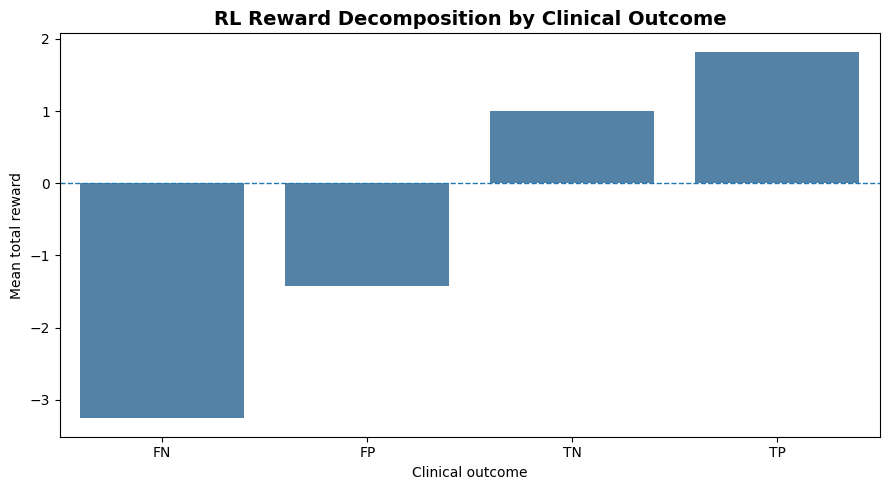

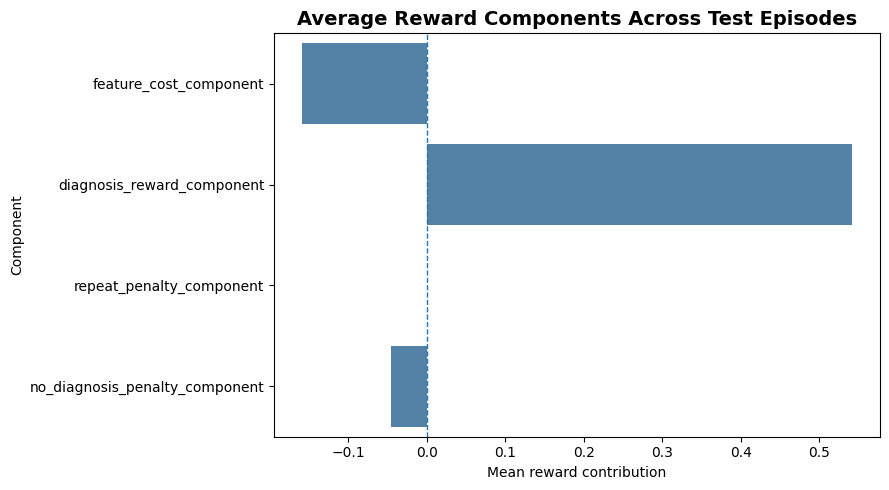

In [19]:
reward_summary = test_eval_df.groupby("outcome").agg(
    count=("outcome", "size"),
    mean_reward=("total_reward", "mean"),
    mean_features_used=("n_features_used", "mean"),
    mean_feature_cost=("feature_cost_component", "mean"),
    mean_diagnosis_reward=("diagnosis_reward_component", "mean"),
    mean_no_diagnosis_penalty=("no_diagnosis_penalty_component", "mean"),
    mean_risk=("risk_score", "mean"),
).reset_index()

display(reward_summary)
reward_summary.to_csv(OUTPUT_DIR / "xai_reward_decomposition_by_outcome.csv", index=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=reward_summary, x="outcome", y="mean_reward", color="steelblue")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("RL Reward Decomposition by Clinical Outcome", fontsize=14, weight="bold")
plt.xlabel("Clinical outcome")
plt.ylabel("Mean total reward")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_reward_by_outcome.png", dpi=220, bbox_inches="tight")
plt.show()

reward_components_df = test_eval_df[
    [
        "feature_cost_component",
        "diagnosis_reward_component",
        "repeat_penalty_component",
        "no_diagnosis_penalty_component",
    ]
].mean().reset_index()
reward_components_df.columns = ["reward_component", "mean_value"]

plt.figure(figsize=(9, 5))
sns.barplot(data=reward_components_df, x="mean_value", y="reward_component", color="steelblue")
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Average Reward Components Across Test Episodes", fontsize=14, weight="bold")
plt.xlabel("Mean reward contribution")
plt.ylabel("Component")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_average_reward_components.png", dpi=220, bbox_inches="tight")
plt.show()

## 17. Action-space heatmap and feature-position analysis

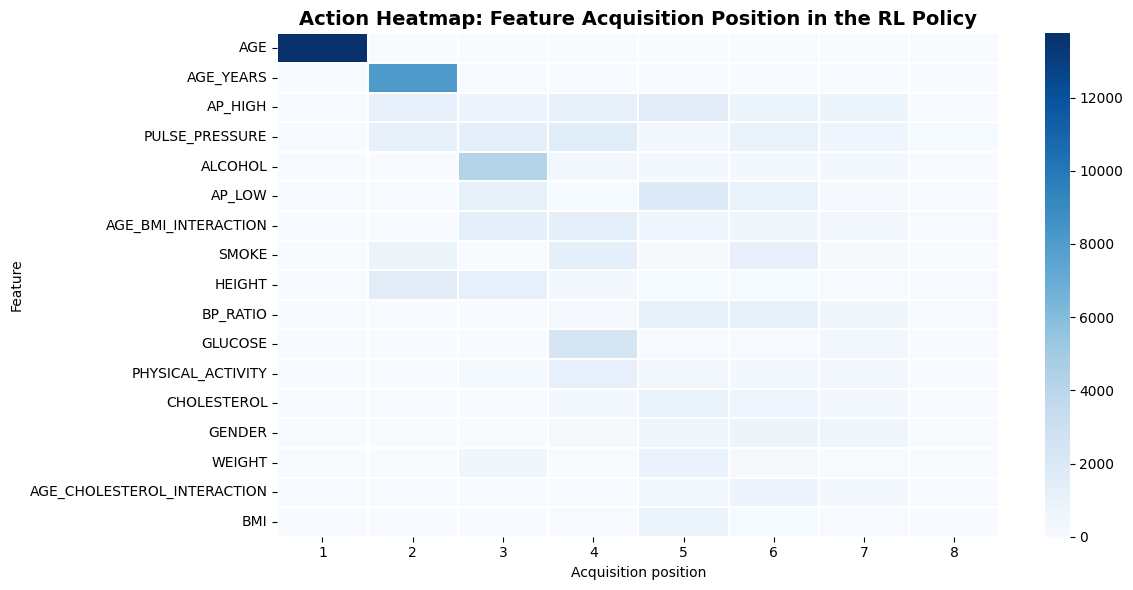

,feature,position
0,AGE,1.000000
3,AGE_YEARS,2.073065
12,HEIGHT,3.115891
4,ALCOHOL,3.609680
14,PULSE_PRESSURE,4.203188
15,SMOKE,4.397943
5,AP_HIGH,4.431131
1,AGE_BMI_INTERACTION,4.457730
11,GLUCOSE,4.522591
16,WEIGHT,4.572727


In [20]:
position_records = []
for traj in test_trajectories:
    for pos, feature in enumerate(traj["feature_sequence"], start=1):
        position_records.append({
            "feature": feature,
            "position": pos,
            "true_label": traj["true_label"],
            "prediction": traj["prediction"],
            "outcome": "correct" if traj["true_label"] == traj["prediction"] else "incorrect",
        })

position_df = pd.DataFrame(position_records)

if len(position_df) > 0:
    position_table = pd.crosstab(position_df["feature"], position_df["position"])
    position_table = position_table.reindex(feature_acquisition_df["feature"].tolist()).fillna(0)

    plt.figure(figsize=(12, max(6, 0.35 * len(position_table))))
    sns.heatmap(position_table, cmap="Blues", linewidths=0.3)
    plt.title("Action Heatmap: Feature Acquisition Position in the RL Policy", fontsize=14, weight="bold")
    plt.xlabel("Acquisition position")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "16_feature_acquisition_position_heatmap.png", dpi=220, bbox_inches="tight")
    plt.show()

    mean_position = position_df.groupby("feature")["position"].mean().reset_index().sort_values("position")
    display(mean_position)
    mean_position.to_csv(OUTPUT_DIR / "xai_mean_feature_acquisition_position.csv", index=False)
else:
    print("No feature acquisition records were collected.")

## 18. Transparent policy distillation into a decision tree

Policy distillation fidelity: 0.4673
This is the agreement between the transparent decision tree and the DQN policy actions.

Distilled policy rules:
|--- step_fraction <= 0.06
|   |--- class: 0
|--- step_fraction >  0.06
|   |--- step_fraction <= 0.19
|   |   |--- observed_value__AGE <= 0.77
|   |   |   |--- observed_value__AGE <= -0.27
|   |   |   |   |--- class: 11
|   |   |   |--- observed_value__AGE >  -0.27
|   |   |   |   |--- observed_value__AGE <= 0.17
|   |   |   |   |   |--- class: 13
|   |   |   |   |--- observed_value__AGE >  0.17
|   |   |   |   |   |--- class: 11
|   |   |--- observed_value__AGE >  0.77
|   |   |   |--- observed_value__AGE <= 1.51
|   |   |   |   |--- observed_value__AGE <= 1.06
|   |   |   |   |   |--- class: 18
|   |   |   |   |--- observed_value__AGE >  1.06
|   |   |   |   |   |--- class: 2
|   |   |   |--- observed_value__AGE >  1.51
|   |   |   |   |--- class: 8
|   |--- step_fraction >  0.19
|   |   |--- step_fraction <= 0.81
|   |   |   |--- step

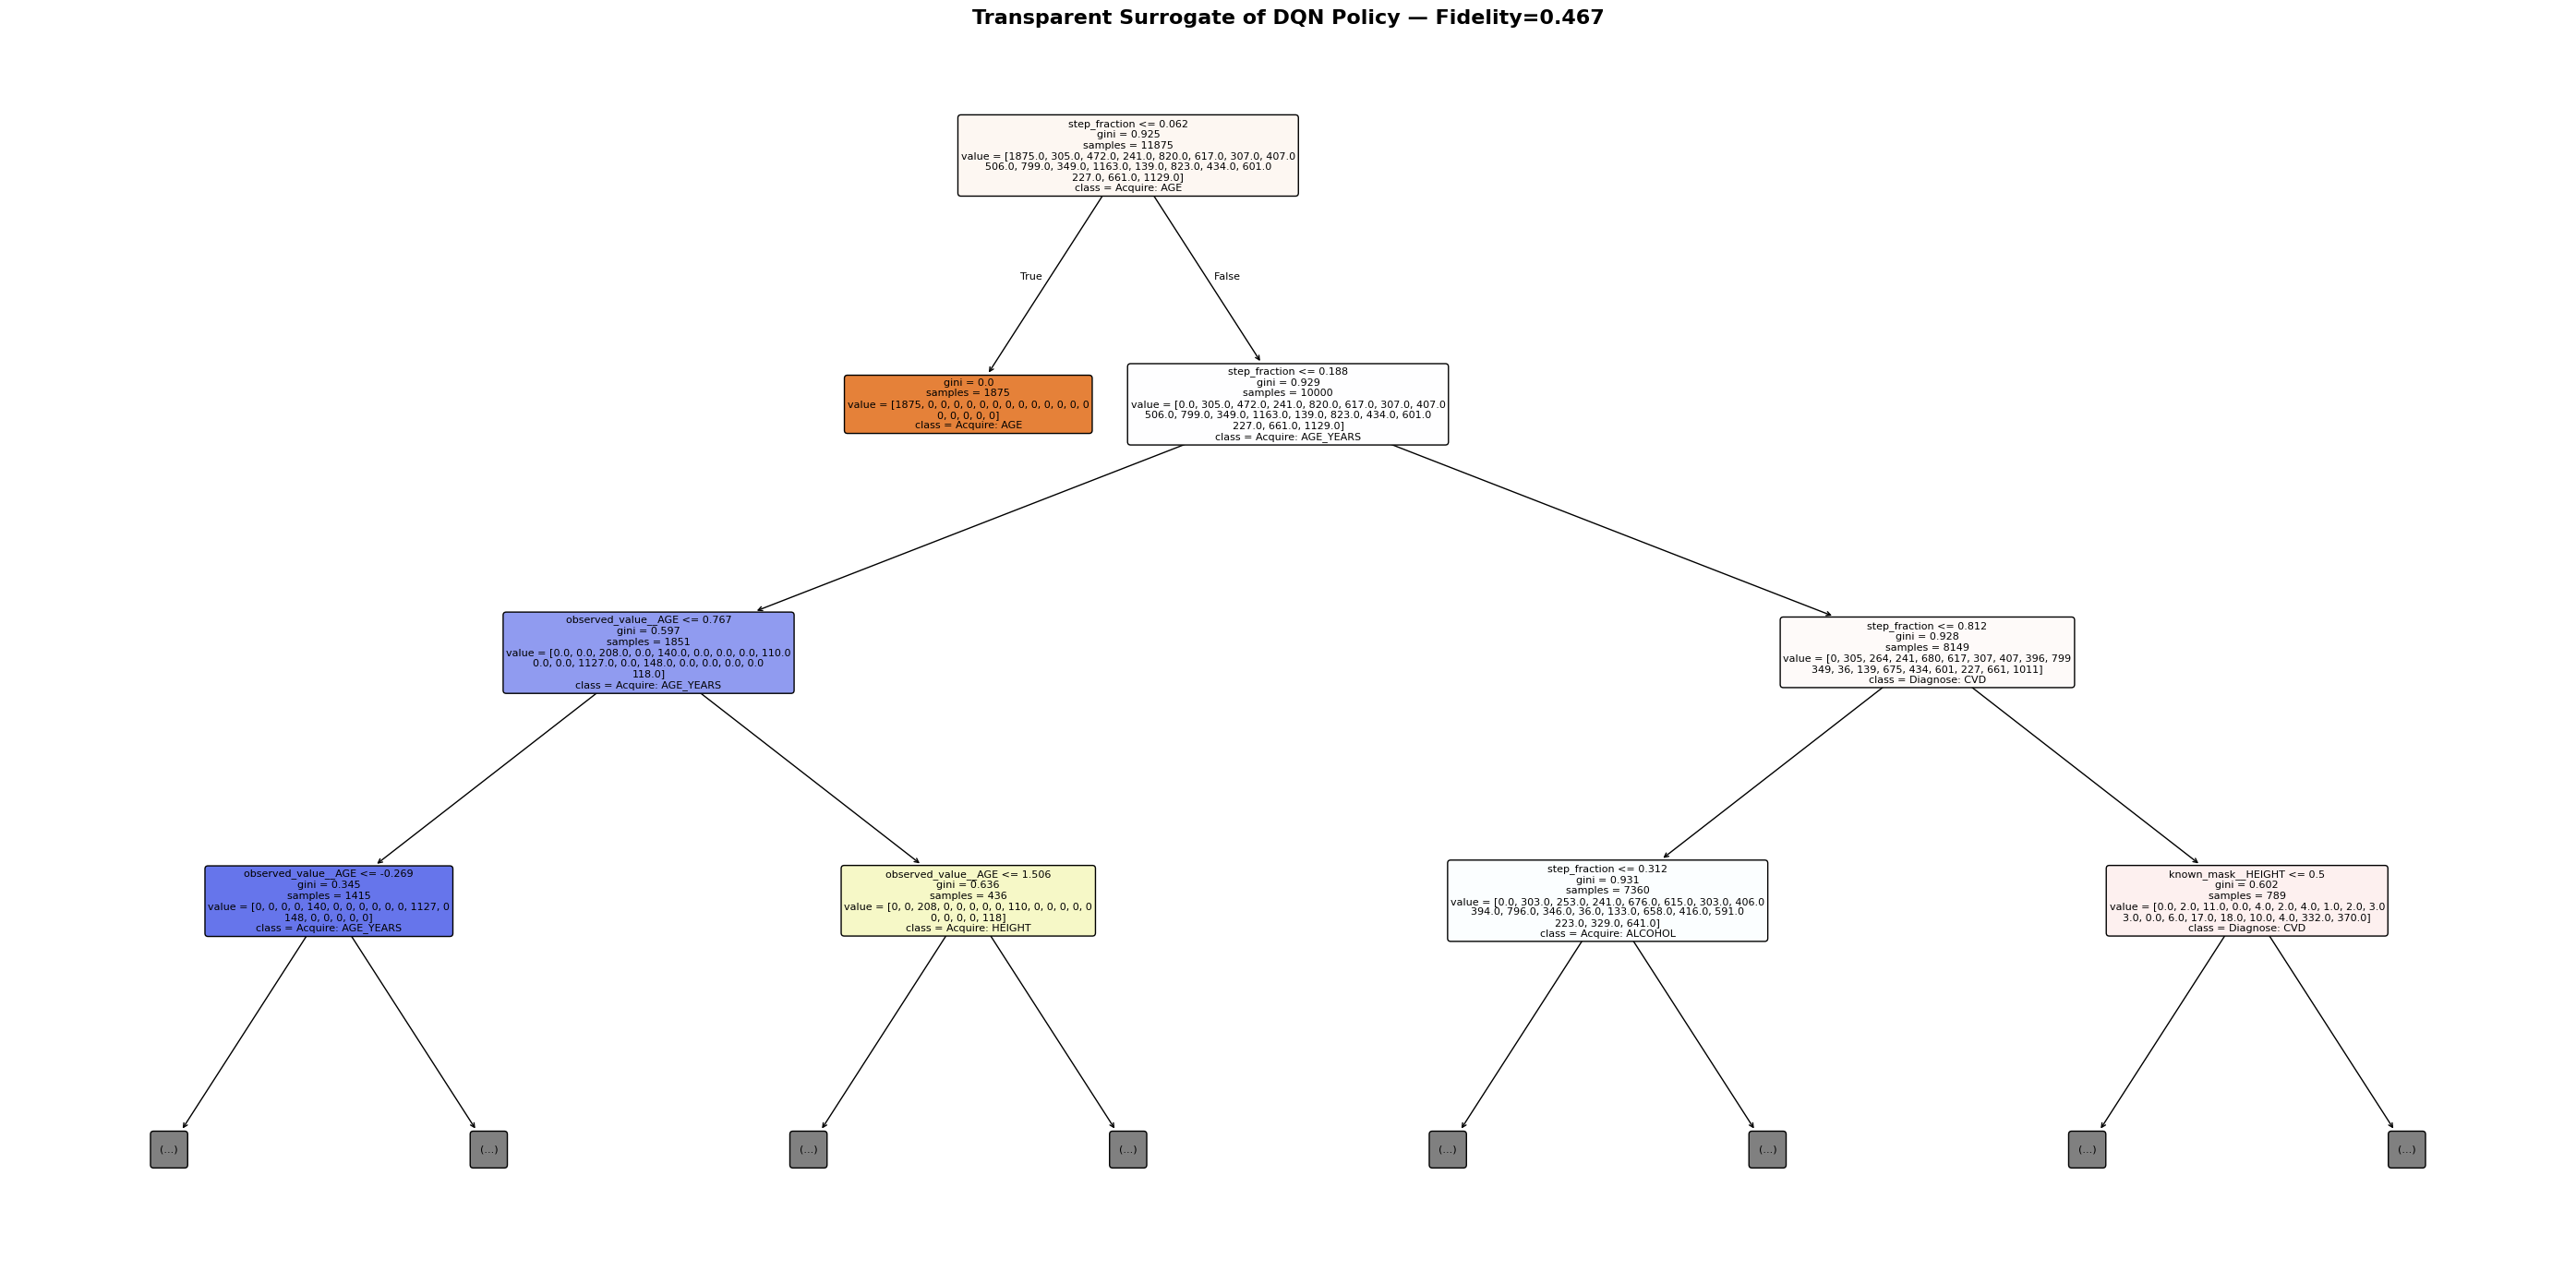

,state_feature,importance
34,step_fraction,0.682548
0,observed_value__AGE,0.287374
19,known_mask__HEIGHT,0.013800
4,observed_value__AP_HIGH,0.013695
32,known_mask__AGE_BMI_INTERACTION,0.002583
2,observed_value__HEIGHT,0.000000
1,observed_value__GENDER,0.000000
7,observed_value__GLUCOSE,0.000000
3,observed_value__WEIGHT,0.000000
5,observed_value__AP_LOW,0.000000


In [21]:
def collect_policy_state_action_samples(X_array, max_patients=1000):
    distill_env = CardiovascularFeatureAcquisitionEnv(
        X_array,
        np.zeros(len(X_array), dtype=int),
        feature_names_rl,
        max_steps=MAX_STEPS,
        feature_cost=FEATURE_COST,
        repeat_feature_penalty=REPEAT_FEATURE_PENALTY,
        no_diagnosis_penalty=NO_DIAGNOSIS_PENALTY,
        seed=RANDOM_STATE + 123,
    )

    n = min(max_patients, len(X_array))
    state_rows = []
    action_labels = []
    policy_net.eval()

    for idx in range(n):
        state = distill_env.reset(index=idx)
        for _ in range(MAX_STEPS + 2):
            valid_mask = distill_env.valid_action_mask()
            with torch.no_grad():
                q_values = policy_net(torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)).cpu().numpy()[0]
            q_values[~valid_mask] = -1e9
            action = int(np.argmax(q_values))

            state_rows.append(state.copy())
            action_labels.append(action)

            next_state, reward, done, info = distill_env.step(action)
            state = next_state

            if done:
                break

    return np.asarray(state_rows, dtype=np.float32), np.asarray(action_labels, dtype=int)

distill_X, distill_y = collect_policy_state_action_samples(
    X_train_rl,
    max_patients=min(2500 if not FAST_MODE else 600, len(X_train_rl)),
)

state_feature_names = (
    [f"observed_value__{f}" for f in feature_names_rl]
    + [f"known_mask__{f}" for f in feature_names_rl]
    + ["step_fraction"]
)
action_names = [f"Acquire: {f}" for f in feature_names_rl] + ["Diagnose: No CVD", "Diagnose: CVD"]

distill_X_train, distill_X_test, distill_y_train, distill_y_test = train_test_split(
    distill_X,
    distill_y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=distill_y if len(np.unique(distill_y)) > 1 else None,
)

distilled_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=30,
    random_state=RANDOM_STATE,
)
distilled_tree.fit(distill_X_train, distill_y_train)

tree_pred = distilled_tree.predict(distill_X_test)
distillation_fidelity = accuracy_score(distill_y_test, tree_pred)

print(f"Policy distillation fidelity: {distillation_fidelity:.4f}")
print("This is the agreement between the transparent decision tree and the DQN policy actions.")

tree_rules = export_text(
    distilled_tree,
    feature_names=state_feature_names,
    max_depth=5,
)
print("\nDistilled policy rules:")
print(tree_rules[:5000])

with open(OUTPUT_DIR / "xai_distilled_policy_tree_rules.txt", "w", encoding="utf-8") as f:
    f.write(tree_rules)

plt.figure(figsize=(28, 14))
class_names_for_tree = [action_names[i] for i in sorted(np.unique(distill_y))]
plot_tree(
    distilled_tree,
    feature_names=state_feature_names,
    class_names=class_names_for_tree,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title(f"Transparent Surrogate of DQN Policy — Fidelity={distillation_fidelity:.3f}", fontsize=16, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "17_distilled_policy_tree.png", dpi=220, bbox_inches="tight")
plt.show()

distilled_feature_importance = pd.DataFrame({
    "state_feature": state_feature_names,
    "importance": distilled_tree.feature_importances_,
}).sort_values("importance", ascending=False)

display(distilled_feature_importance.head(20))
distilled_feature_importance.to_csv(OUTPUT_DIR / "xai_distilled_tree_feature_importance.csv", index=False)

## 19. Common prediction wrapper for post-hoc XAI

In [22]:
def build_full_observed_state_matrix(X_features):
    X_features = np.asarray(X_features, dtype=np.float32)
    if X_features.ndim == 1:
        X_features = X_features.reshape(1, -1)
    known_mask = np.ones_like(X_features, dtype=np.float32)
    step_fraction = np.ones((X_features.shape[0], 1), dtype=np.float32)
    return np.concatenate([X_features, known_mask, step_fraction], axis=1).astype(np.float32)

def rl_diagnosis_proba_from_features(X_features):
    states = build_full_observed_state_matrix(X_features)
    policy_net.eval()
    with torch.no_grad():
        states_t = torch.tensor(states, dtype=torch.float32, device=DEVICE)
        q_values = policy_net(states_t)
        diag_q = q_values[:, [train_env.action_diagnose_no, train_env.action_diagnose_yes]]
        probs = torch.softmax(diag_q, dim=1).cpu().numpy()
    return probs

def rl_cvd_probability(X_features):
    return rl_diagnosis_proba_from_features(X_features)[:, 1]

sample_probs = rl_diagnosis_proba_from_features(X_test_rl[:5])
print(sample_probs)
print("Each row should sum to 1:", sample_probs.sum(axis=1))

[[0.6394481  0.36055183]
 [0.0478267  0.95217335]
 [0.18660706 0.813393  ]
 [0.02273423 0.9772658 ]
 [0.00615335 0.9938466 ]]
Each row should sum to 1: [0.99999994 1.         1.         1.         0.99999994]


## 20. SHAP explanations of the RL diagnosis policy

SHAP background shape: (40, 17)
SHAP explanation sample shape: (80, 17)


,feature,mean_abs_shap
4,AP_HIGH,0.101537
5,AP_LOW,0.073535
15,AGE_BMI_INTERACTION,0.059876
12,BMI,0.043523
11,AGE_YEARS,0.035594
0,AGE,0.032815
8,SMOKE,0.027571
16,AGE_CHOLESTEROL_INTERACTION,0.024077
6,CHOLESTEROL,0.020067
13,PULSE_PRESSURE,0.018941


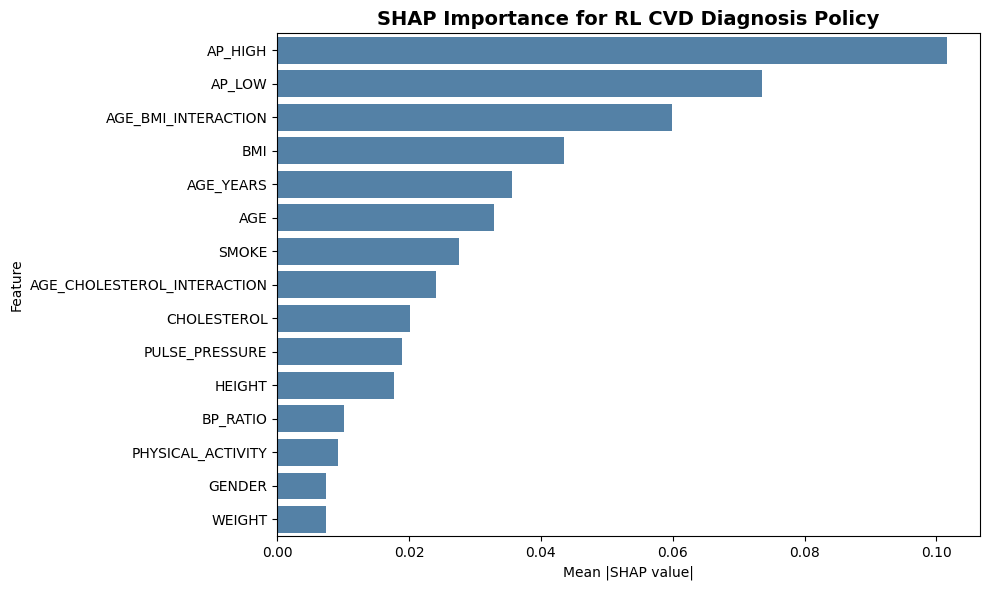

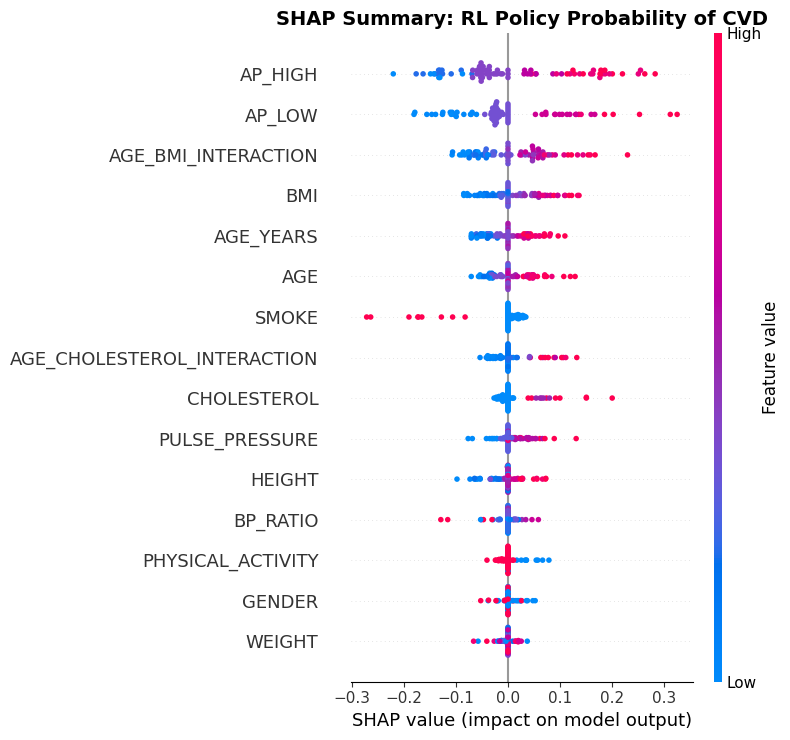

In [23]:
shap_importance_df = pd.DataFrame()

if SHAP_AVAILABLE:
    try:
        rng = np.random.default_rng(RANDOM_STATE)
        bg_size = min(XAI_BACKGROUND_SIZE, len(X_train_rl))
        sample_size = min(XAI_SAMPLE_SIZE, len(X_test_rl))

        background_idx = rng.choice(len(X_train_rl), size=bg_size, replace=False)
        sample_idx = rng.choice(len(X_test_rl), size=sample_size, replace=False)

        shap_background = pd.DataFrame(X_train_rl[background_idx], columns=feature_names_rl)
        shap_sample = pd.DataFrame(X_test_rl[sample_idx], columns=feature_names_rl)

        print(f"SHAP background shape: {shap_background.shape}")
        print(f"SHAP explanation sample shape: {shap_sample.shape}")

        shap_explainer = shap.KernelExplainer(
            lambda data: rl_cvd_probability(data),
            shap_background,
        )

        shap_values = shap_explainer.shap_values(
            shap_sample,
            nsamples=min(150, 2 * len(feature_names_rl) + 80),
            silent=True,
        )

        shap_values_array = np.asarray(shap_values)
        if shap_values_array.ndim == 3:
            shap_values_array = shap_values_array[:, :, -1]

        shap_importance = np.abs(shap_values_array).mean(axis=0)

        shap_importance_df = pd.DataFrame({
            "feature": feature_names_rl,
            "mean_abs_shap": shap_importance,
        }).sort_values("mean_abs_shap", ascending=False)

        display(shap_importance_df)
        shap_importance_df.to_csv(OUTPUT_DIR / "xai_shap_rl_policy_importance.csv", index=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=shap_importance_df.head(15), x="mean_abs_shap", y="feature", color="steelblue")
        plt.title("SHAP Importance for RL CVD Diagnosis Policy", fontsize=14, weight="bold")
        plt.xlabel("Mean |SHAP value|")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "18_shap_rl_policy_importance.png", dpi=220, bbox_inches="tight")
        plt.show()

        shap.summary_plot(
            shap_values_array,
            shap_sample,
            feature_names=feature_names_rl,
            show=False,
            max_display=15,
        )
        plt.title("SHAP Summary: RL Policy Probability of CVD", fontsize=14, weight="bold")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "19_shap_summary_rl_policy.png", dpi=220, bbox_inches="tight")
        plt.show()

    except Exception as exc:
        print(f"SHAP section skipped due to an error: {exc}")
else:
    print("SHAP is unavailable in this environment.")

## 21. LIME local explanations

LIME explanation for patient 1
True label: CVD
[('AP_LOW <= -0.14', -0.24350779206691384), ('SMOKE <= -0.31', 0.1607547509916993), ('-0.39 < AP_HIGH <= 0.80', 0.11898513217597534), ('PULSE_PRESSURE > 0.39', 0.07759896550847048), ('CHOLESTEROL <= -0.54', -0.07482413710977433), ('GLUCOSE <= -0.39', 0.06601825520150581), ('HEIGHT <= -0.66', -0.04786753162553525), ('-0.61 < BMI <= -0.20', -0.03904404787477616), ('-0.59 < AGE_CHOLESTEROL_INTERACTION <= -0.44', -0.037664607759191594), ('0.10 < AGE <= 0.69', 0.03201313505209397)]


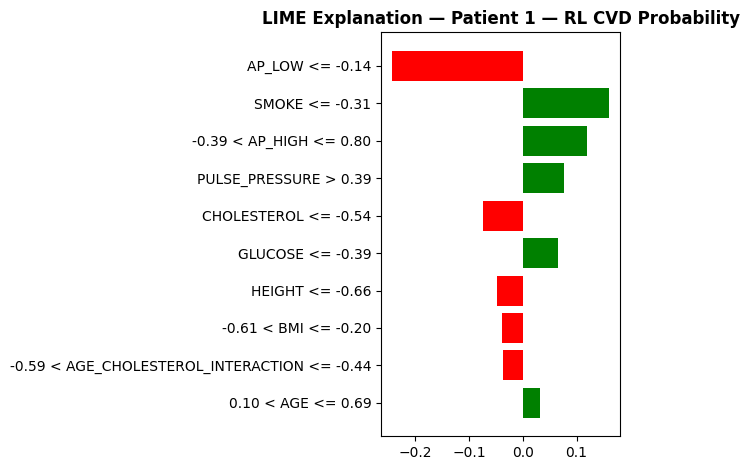

LIME explanation for patient 6
True label: CVD
[('AP_LOW <= -0.14', -0.24618010279508848), ('AP_HIGH <= -0.39', -0.22897179501777737), ('SMOKE <= -0.31', 0.14628325702626943), ('BMI > 0.43', 0.1342757501059727), ('CHOLESTEROL <= -0.54', -0.07219096732150568), ('PULSE_PRESSURE <= -0.43', -0.07058137347992721), ('AGE_CHOLESTEROL_INTERACTION <= -0.59', -0.060608823693176696), ('GLUCOSE <= -0.39', 0.051814904096068745), ('ALCOHOL <= -0.24', -0.048256624841781386), ('HEIGHT > 0.69', 0.04214312488775862)]


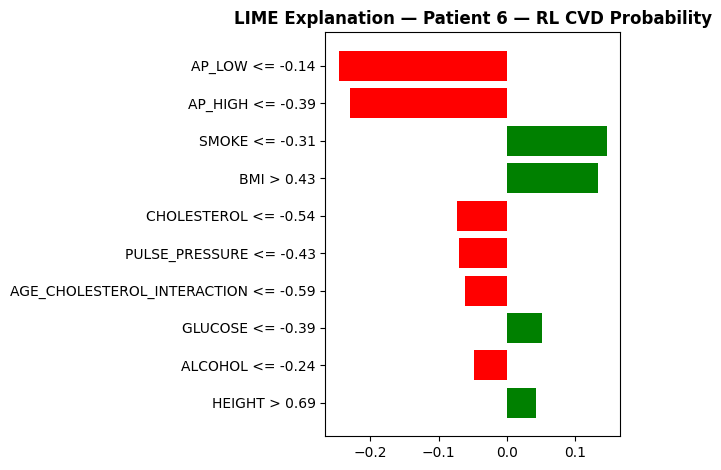

LIME explanation for patient 0
True label: No CVD
[('AP_LOW <= -0.14', -0.25890521740120914), ('AP_HIGH <= -0.39', -0.23068449115099918), ('SMOKE <= -0.31', 0.17863919434018452), ('BMI <= -0.61', -0.10968072674948111), ('AGE > 0.69', 0.09431958415051098), ('CHOLESTEROL <= -0.54', -0.07590965350011808), ('PULSE_PRESSURE <= -0.43', -0.07144381590651323), ('GLUCOSE <= -0.39', 0.06901873720361239), ('AGE_YEARS > 0.69', 0.06800156531935078), ('HEIGHT <= -0.66', -0.0480299769460624)]


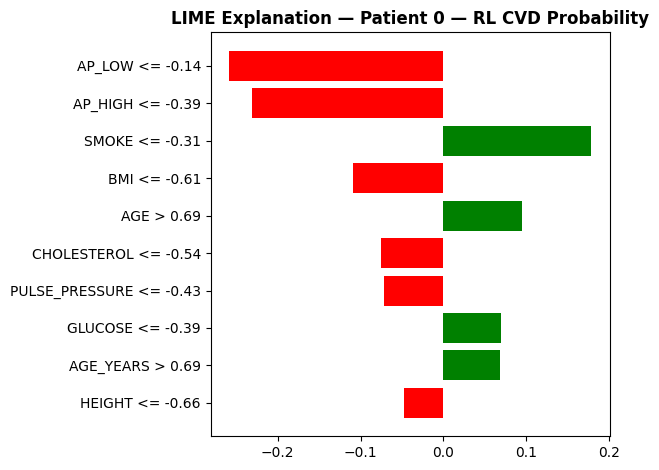

In [24]:
lime_explanations = []

if LIME_AVAILABLE:
    try:
        lime_explainer = LimeTabularExplainer(
            training_data=np.asarray(X_train_rl, dtype=np.float64),
            feature_names=feature_names_rl,
            class_names=class_names,
            mode="classification",
            discretize_continuous=True,
            random_state=RANDOM_STATE,
        )

        candidate_indices = []
        for outcome in ["TP", "FN", "FP", "TN"]:
            subset = test_eval_df[test_eval_df["outcome"] == outcome]
            if len(subset) > 0:
                candidate_indices.append(int(subset.iloc[0]["index"]))
        candidate_indices = candidate_indices[:LIME_EXAMPLES]

        for idx in candidate_indices:
            exp = lime_explainer.explain_instance(
                data_row=X_test_rl[idx].astype(np.float64),
                predict_fn=rl_diagnosis_proba_from_features,
                num_features=min(10, len(feature_names_rl)),
                labels=[1],
            )

            explanation_list = exp.as_list(label=1)
            lime_explanations.append({
                "patient_index": idx,
                "true_label": int(y_test.values[idx]),
                "prediction": int(test_eval_df.loc[test_eval_df["index"] == idx, "prediction"].iloc[0]),
                "risk_score": float(test_eval_df.loc[test_eval_df["index"] == idx, "risk_score"].iloc[0]),
                "lime_explanation": explanation_list,
            })

            print("=" * 100)
            print(f"LIME explanation for patient {idx}")
            print(f"True label: {class_names[int(y_test.values[idx])]}")
            print(explanation_list)

            fig = exp.as_pyplot_figure(label=1)
            plt.title(f"LIME Explanation — Patient {idx} — RL CVD Probability", fontsize=12, weight="bold")
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f"20_lime_patient_{idx}.png", dpi=220, bbox_inches="tight")
            plt.show()

        with open(OUTPUT_DIR / "xai_lime_explanations.json", "w", encoding="utf-8") as f:
            json.dump(lime_explanations, f, indent=4, default=str)

    except Exception as exc:
        print(f"LIME section skipped due to an error: {exc}")
else:
    print("LIME is unavailable in this environment.")

## 22. Integrated Gradients for the RL Q-policy

,feature,mean_abs_integrated_gradient
4,AP_HIGH,0.252295
5,AP_LOW,0.225392
16,AGE_CHOLESTEROL_INTERACTION,0.144119
15,AGE_BMI_INTERACTION,0.129375
0,AGE,0.107510
6,CHOLESTEROL,0.097378
12,BMI,0.096090
8,SMOKE,0.078426
2,HEIGHT,0.073661
14,BP_RATIO,0.067571


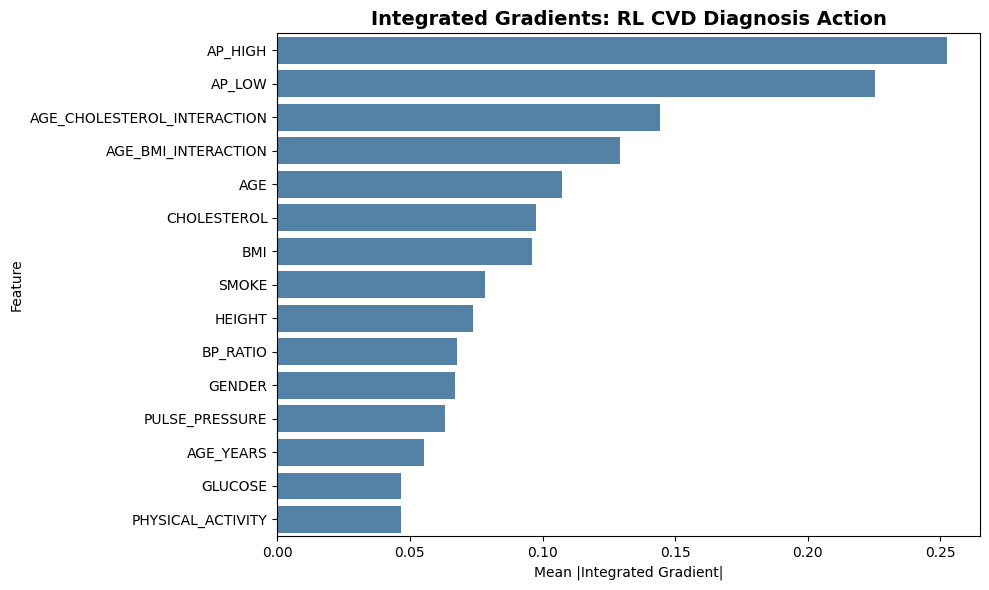

In [25]:
def integrated_gradients_single(x_features, target_action, baseline=None, steps=40):
    x_features = np.asarray(x_features, dtype=np.float32).reshape(1, -1)
    if baseline is None:
        baseline = np.zeros_like(x_features, dtype=np.float32)
    else:
        baseline = np.asarray(baseline, dtype=np.float32).reshape(1, -1)

    alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1)
    x_t = torch.tensor(x_features, dtype=torch.float32, device=DEVICE)
    baseline_t = torch.tensor(baseline, dtype=torch.float32, device=DEVICE)

    scaled_features = baseline_t + alphas * (x_t - baseline_t)
    masks = torch.ones_like(scaled_features, device=DEVICE)
    step_fraction = torch.ones((steps, 1), dtype=torch.float32, device=DEVICE)
    states = torch.cat([scaled_features, masks, step_fraction], dim=1)
    states.requires_grad_(True)

    policy_net.eval()
    q_target = policy_net(states)[:, target_action].sum()
    grads = torch.autograd.grad(q_target, states)[0][:, : len(feature_names_rl)]

    avg_grads = grads.mean(dim=0)
    ig = (x_t - baseline_t).squeeze(0) * avg_grads
    return ig.detach().cpu().numpy()

def integrated_gradients_batch(X_sample, target_action, steps=40):
    attributions = []
    baseline = np.zeros((1, X_sample.shape[1]), dtype=np.float32)
    for row in X_sample:
        attributions.append(integrated_gradients_single(row, target_action, baseline=baseline, steps=steps))
    return np.asarray(attributions)

ig_sample_size = min(XAI_SAMPLE_SIZE, len(X_test_rl))
rng = np.random.default_rng(RANDOM_STATE)
ig_indices = rng.choice(len(X_test_rl), size=ig_sample_size, replace=False)
X_ig_sample = X_test_rl[ig_indices]

ig_attr = integrated_gradients_batch(
    X_ig_sample,
    target_action=train_env.action_diagnose_yes,
    steps=IG_STEPS,
)

ig_importance = np.abs(ig_attr).mean(axis=0)
ig_importance_df = pd.DataFrame({
    "feature": feature_names_rl,
    "mean_abs_integrated_gradient": ig_importance,
}).sort_values("mean_abs_integrated_gradient", ascending=False)

display(ig_importance_df)
ig_importance_df.to_csv(OUTPUT_DIR / "xai_integrated_gradients_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=ig_importance_df.head(15), x="mean_abs_integrated_gradient", y="feature", color="steelblue")
plt.title("Integrated Gradients: RL CVD Diagnosis Action", fontsize=14, weight="bold")
plt.xlabel("Mean |Integrated Gradient|")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "21_integrated_gradients_importance.png", dpi=220, bbox_inches="tight")
plt.show()

## 23. Gradient × Input saliency

,feature,mean_abs_gradient_x_input
5,AP_LOW,0.260575
4,AP_HIGH,0.186991
16,AGE_CHOLESTEROL_INTERACTION,0.185762
6,CHOLESTEROL,0.147212
11,AGE_YEARS,0.129082
15,AGE_BMI_INTERACTION,0.128974
1,GENDER,0.114009
0,AGE,0.113378
8,SMOKE,0.096931
12,BMI,0.092241


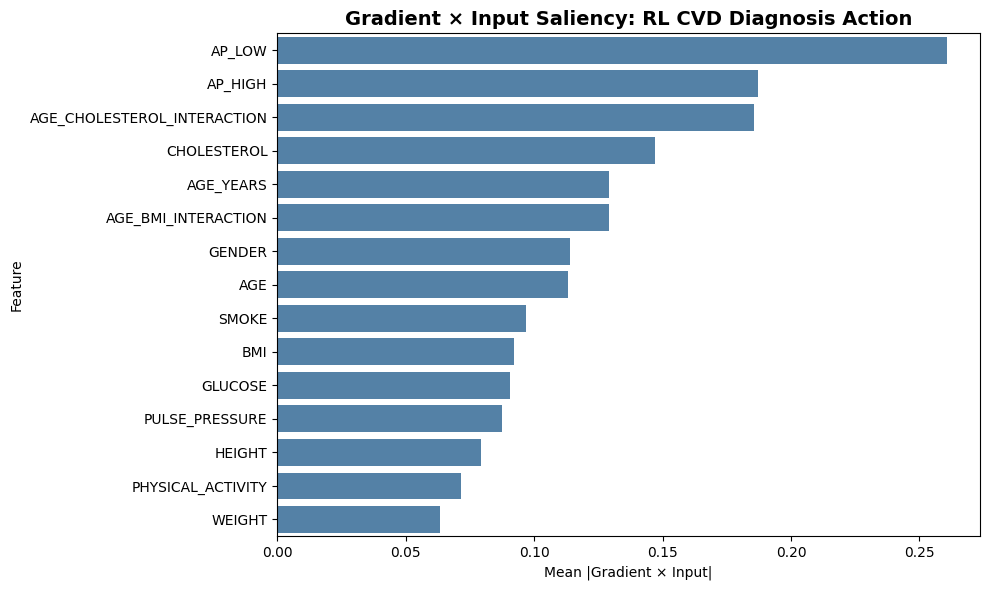

In [26]:
def gradient_x_input_batch(X_sample, target_action):
    X_sample = np.asarray(X_sample, dtype=np.float32)
    states_np = build_full_observed_state_matrix(X_sample)
    states = torch.tensor(states_np, dtype=torch.float32, device=DEVICE, requires_grad=True)

    policy_net.eval()
    q_target = policy_net(states)[:, target_action].sum()

    policy_net.zero_grad(set_to_none=True)
    q_target.backward()

    grads = states.grad[:, : len(feature_names_rl)]
    values = states[:, : len(feature_names_rl)]
    grad_x_input = grads * values

    return grad_x_input.detach().cpu().numpy()

gxi_attr = gradient_x_input_batch(
    X_ig_sample,
    target_action=train_env.action_diagnose_yes,
)

gxi_importance = np.abs(gxi_attr).mean(axis=0)
gxi_importance_df = pd.DataFrame({
    "feature": feature_names_rl,
    "mean_abs_gradient_x_input": gxi_importance,
}).sort_values("mean_abs_gradient_x_input", ascending=False)

display(gxi_importance_df)
gxi_importance_df.to_csv(OUTPUT_DIR / "xai_gradient_x_input_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=gxi_importance_df.head(15), x="mean_abs_gradient_x_input", y="feature", color="steelblue")
plt.title("Gradient × Input Saliency: RL CVD Diagnosis Action", fontsize=14, weight="bold")
plt.xlabel("Mean |Gradient × Input|")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "22_gradient_x_input_importance.png", dpi=220, bbox_inches="tight")
plt.show()

## 24. Occlusion sensitivity analysis

,feature,mean_abs_probability_change,mean_signed_probability_change
4,AP_HIGH,0.061775,-0.028542
5,AP_LOW,0.045746,0.005867
15,AGE_BMI_INTERACTION,0.037835,-0.002105
16,AGE_CHOLESTEROL_INTERACTION,0.032966,-0.011194
12,BMI,0.031336,-0.010074
6,CHOLESTEROL,0.030126,-0.007773
11,AGE_YEARS,0.029904,0.000970
8,SMOKE,0.028967,-0.013709
13,PULSE_PRESSURE,0.024347,-0.018066
0,AGE,0.024291,-0.000375


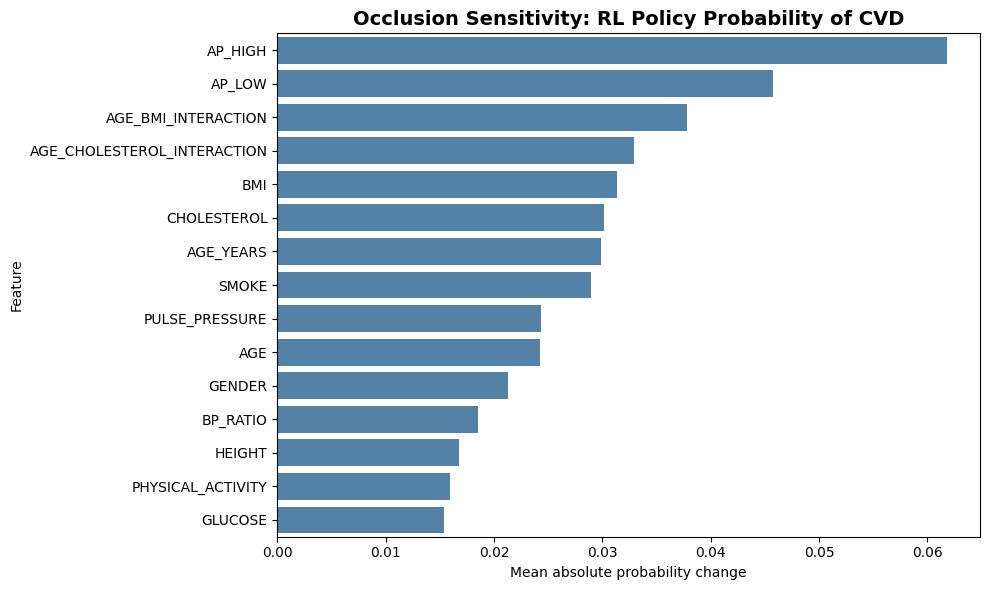

In [27]:
def occlusion_importance(X_sample, reference_values=None):
    X_sample = np.asarray(X_sample, dtype=np.float32)
    if reference_values is None:
        reference_values = X_train_rl.mean(axis=0)

    base_prob = rl_cvd_probability(X_sample)
    rows = []

    for j, feature in enumerate(feature_names_rl):
        X_occ = X_sample.copy()
        X_occ[:, j] = reference_values[j]
        occ_prob = rl_cvd_probability(X_occ)

        rows.append({
            "feature": feature,
            "mean_abs_probability_change": float(np.mean(np.abs(base_prob - occ_prob))),
            "mean_signed_probability_change": float(np.mean(base_prob - occ_prob)),
        })

    return pd.DataFrame(rows).sort_values("mean_abs_probability_change", ascending=False)

occlusion_df = occlusion_importance(X_ig_sample)
display(occlusion_df)
occlusion_df.to_csv(OUTPUT_DIR / "xai_occlusion_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=occlusion_df.head(15), x="mean_abs_probability_change", y="feature", color="steelblue")
plt.title("Occlusion Sensitivity: RL Policy Probability of CVD", fontsize=14, weight="bold")
plt.xlabel("Mean absolute probability change")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "23_occlusion_sensitivity.png", dpi=220, bbox_inches="tight")
plt.show()

## 25. Counterfactual feature interventions

,patient_index,true_label,feature_changed,intervention,original_probability_cvd,counterfactual_probability_cvd,probability_change,original_prediction,counterfactual_prediction,prediction_flipped
4,1182,1,AGE_BMI_INTERACTION,p10,0.788175,0.312764,-0.475411,1,0,True
21,11810,0,AP_HIGH,p90,0.092281,0.530388,0.438107,0,1,True
0,1182,1,AP_HIGH,p10,0.788175,0.379662,-0.408513,1,0,True
17,9593,0,AGE_CHOLESTEROL_INTERACTION,p90,0.316910,0.692930,0.376020,0,1,True
8,1182,1,BMI,p10,0.788175,0.436288,-0.351886,1,0,True
19,9593,0,BMI,p90,0.316910,0.658678,0.341768,0,1,True
2,1182,1,AP_LOW,p10,0.788175,0.467218,-0.320957,1,0,True
75,10642,1,AGE_BMI_INTERACTION,p90,0.095013,0.360195,0.265182,0,0,False
15,9593,0,AGE_BMI_INTERACTION,p90,0.316910,0.572169,0.255259,0,1,True
25,11810,0,AGE_BMI_INTERACTION,p90,0.092281,0.303785,0.211505,0,0,False


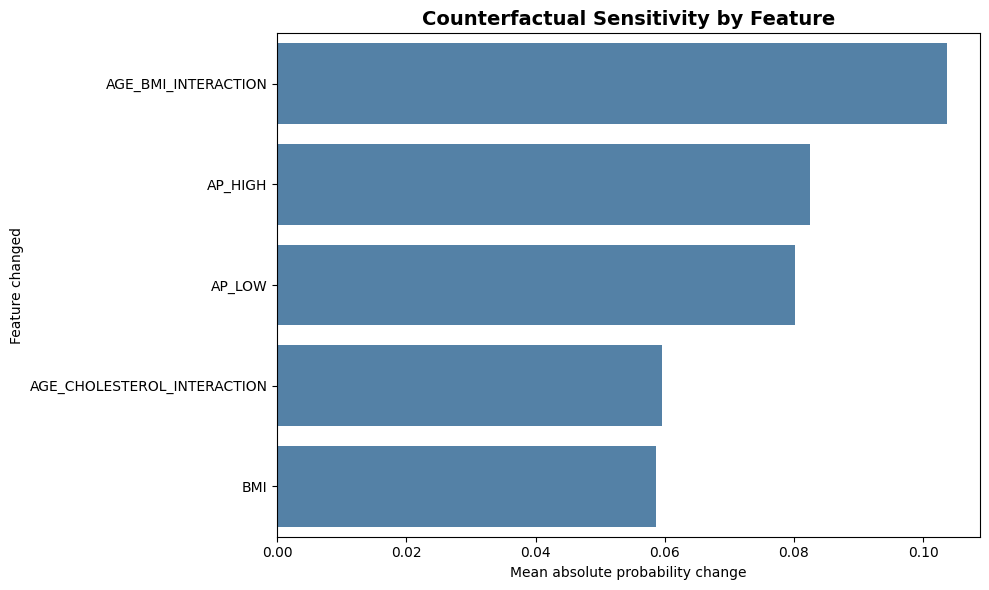

Number of counterfactual flips: 9


In [28]:
top_counterfactual_features = occlusion_df.head(5)["feature"].tolist()
top_counterfactual_indices = [feature_names_rl.index(f) for f in top_counterfactual_features]

cf_records = []
rng = np.random.default_rng(RANDOM_STATE)
cf_indices = rng.choice(len(X_test_rl), size=min(COUNTERFACTUAL_EXAMPLES, len(X_test_rl)), replace=False)

feature_percentiles = {
    j: {
        "p10": float(np.percentile(X_train_rl[:, j], 10)),
        "p90": float(np.percentile(X_train_rl[:, j], 90)),
    }
    for j in top_counterfactual_indices
}

for idx in cf_indices:
    original_x = X_test_rl[idx].copy()
    original_prob = float(rl_cvd_probability(original_x.reshape(1, -1))[0])
    original_pred = int(original_prob >= 0.5)

    for j in top_counterfactual_indices:
        for direction, value in feature_percentiles[j].items():
            cf_x = original_x.copy()
            cf_x[j] = value
            cf_prob = float(rl_cvd_probability(cf_x.reshape(1, -1))[0])
            cf_pred = int(cf_prob >= 0.5)

            cf_records.append({
                "patient_index": int(idx),
                "true_label": int(y_test.values[idx]),
                "feature_changed": feature_names_rl[j],
                "intervention": direction,
                "original_probability_cvd": original_prob,
                "counterfactual_probability_cvd": cf_prob,
                "probability_change": cf_prob - original_prob,
                "original_prediction": original_pred,
                "counterfactual_prediction": cf_pred,
                "prediction_flipped": original_pred != cf_pred,
            })

counterfactual_df = pd.DataFrame(cf_records)
display(counterfactual_df.sort_values("probability_change", key=lambda s: np.abs(s), ascending=False).head(30))
counterfactual_df.to_csv(OUTPUT_DIR / "xai_counterfactual_interventions.csv", index=False)

if len(counterfactual_df) > 0:
    plt.figure(figsize=(10, 6))
    cf_plot_df = counterfactual_df.groupby("feature_changed")["probability_change"].apply(lambda s: np.mean(np.abs(s))).reset_index()
    cf_plot_df = cf_plot_df.sort_values("probability_change", ascending=False)
    sns.barplot(data=cf_plot_df, x="probability_change", y="feature_changed", color="steelblue")
    plt.title("Counterfactual Sensitivity by Feature", fontsize=14, weight="bold")
    plt.xlabel("Mean absolute probability change")
    plt.ylabel("Feature changed")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "24_counterfactual_sensitivity.png", dpi=220, bbox_inches="tight")
    plt.show()

print(f"Number of counterfactual flips: {int(counterfactual_df['prediction_flipped'].sum()) if len(counterfactual_df) else 0}")

## 26. Policy sensitivity curves

,feature,feature_value,mean_policy_probability_cvd
0,AP_HIGH,-1.585699,0.420505
1,AP_HIGH,-0.988216,0.478626
2,AP_HIGH,-0.988216,0.478626
3,AP_HIGH,-0.390733,0.545991
4,AP_HIGH,-0.390733,0.545991


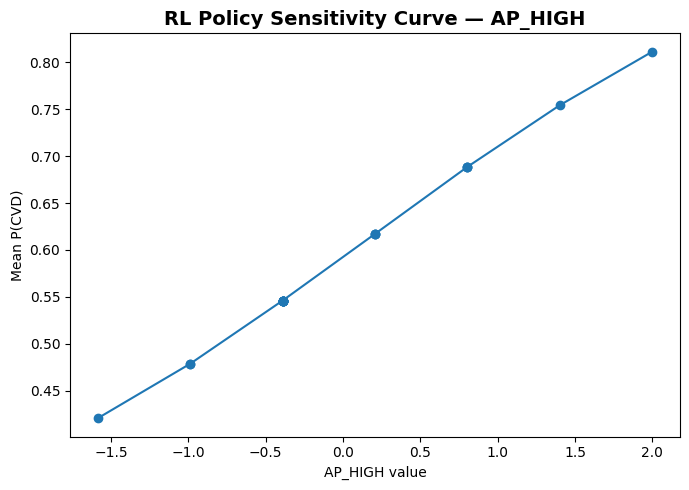

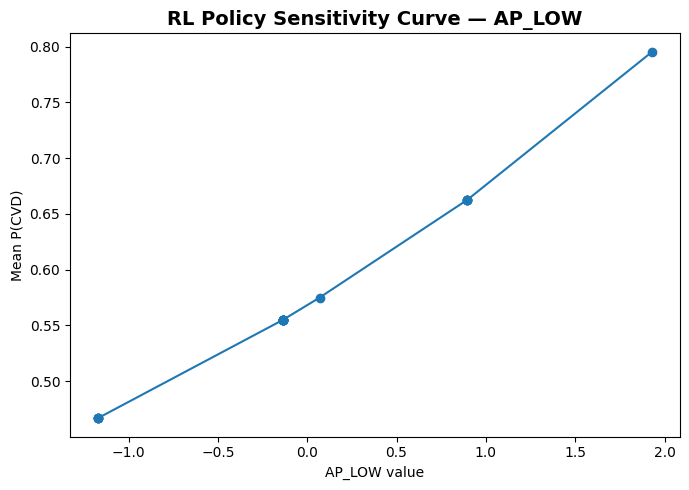

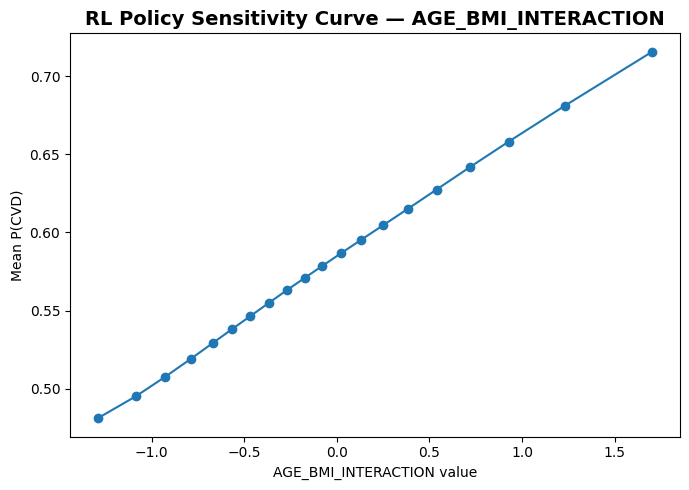

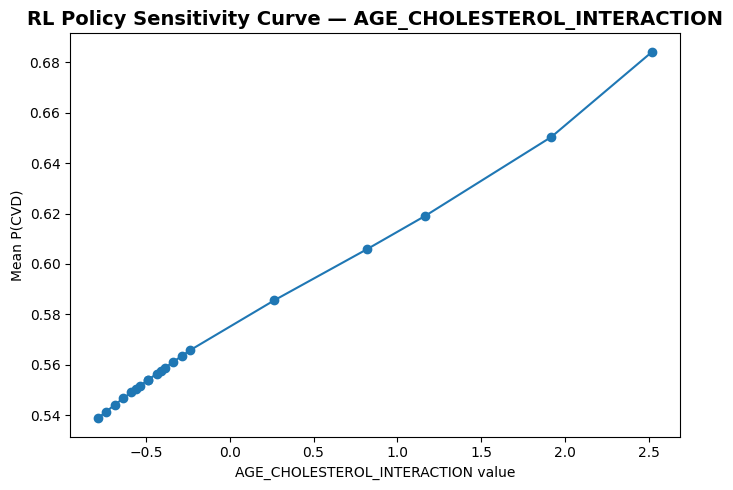

In [29]:
sensitivity_features = occlusion_df.head(min(4, len(occlusion_df)))["feature"].tolist()
sensitivity_indices = [feature_names_rl.index(f) for f in sensitivity_features]

base_sample = X_test_rl[: min(500, len(X_test_rl))].copy()
sensitivity_records = []

for feature, j in zip(sensitivity_features, sensitivity_indices):
    grid = np.percentile(X_train_rl[:, j], np.linspace(5, 95, 20))

    for value in grid:
        X_modified = base_sample.copy()
        X_modified[:, j] = value
        mean_prob = float(rl_cvd_probability(X_modified).mean())
        sensitivity_records.append({
            "feature": feature,
            "feature_value": float(value),
            "mean_policy_probability_cvd": mean_prob,
        })

sensitivity_df = pd.DataFrame(sensitivity_records)
display(sensitivity_df.head())
sensitivity_df.to_csv(OUTPUT_DIR / "xai_policy_sensitivity_curves.csv", index=False)

for feature in sensitivity_features:
    plot_df = sensitivity_df[sensitivity_df["feature"] == feature]
    plt.figure(figsize=(7, 5))
    plt.plot(plot_df["feature_value"], plot_df["mean_policy_probability_cvd"], marker="o")
    plt.title(f"RL Policy Sensitivity Curve — {feature}", fontsize=14, weight="bold")
    plt.xlabel(f"{feature} value")
    plt.ylabel("Mean P(CVD)")
    plt.tight_layout()
    safe_feature = re.sub(r"[^a-zA-Z0-9]+", "_", feature)[:40]
    plt.savefig(OUTPUT_DIR / f"25_policy_sensitivity_{safe_feature}.png", dpi=220, bbox_inches="tight")
    plt.show()

## 27. Comparative XAI agreement across methods

method,Gradient x Input,Integrated Gradients,Occlusion,Policy Acquisition Frequency,SHAP,mean_xai_agreement_score
feature,,,,,,
AP_HIGH,0.653138,1.000000,1.000000,0.393103,1.000000,0.809248
AP_LOW,1.000000,0.873133,0.674057,0.257613,0.714397,0.703840
AGE,0.306144,0.317238,0.237792,1.000000,0.299081,0.432051
AGE_BMI_INTERACTION,0.379659,0.420347,0.513197,0.250573,0.575085,0.427772
AGE_CHOLESTEROL_INTERACTION,0.647345,0.489873,0.414189,0.031322,0.209959,0.358538
AGE_YEARS,0.380169,0.071069,0.351924,0.571146,0.327427,0.340347
CHOLESTEROL,0.465630,0.269456,0.356435,0.082734,0.169059,0.268663
BMI,0.206509,0.263385,0.381031,0.000000,0.408292,0.251843
SMOKE,0.228619,0.180088,0.332875,0.211817,0.245596,0.239799


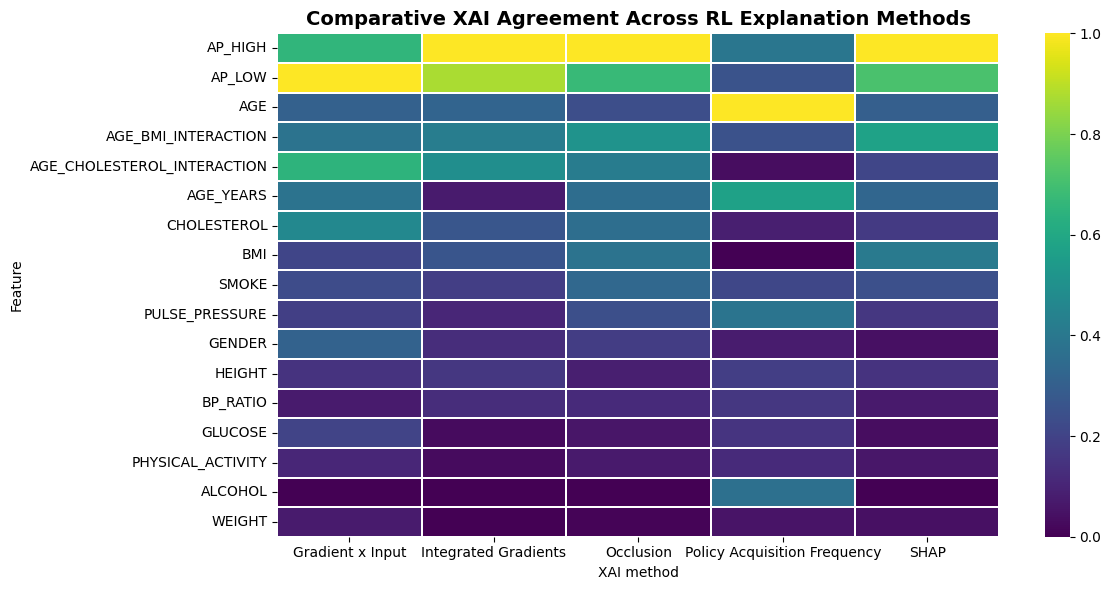

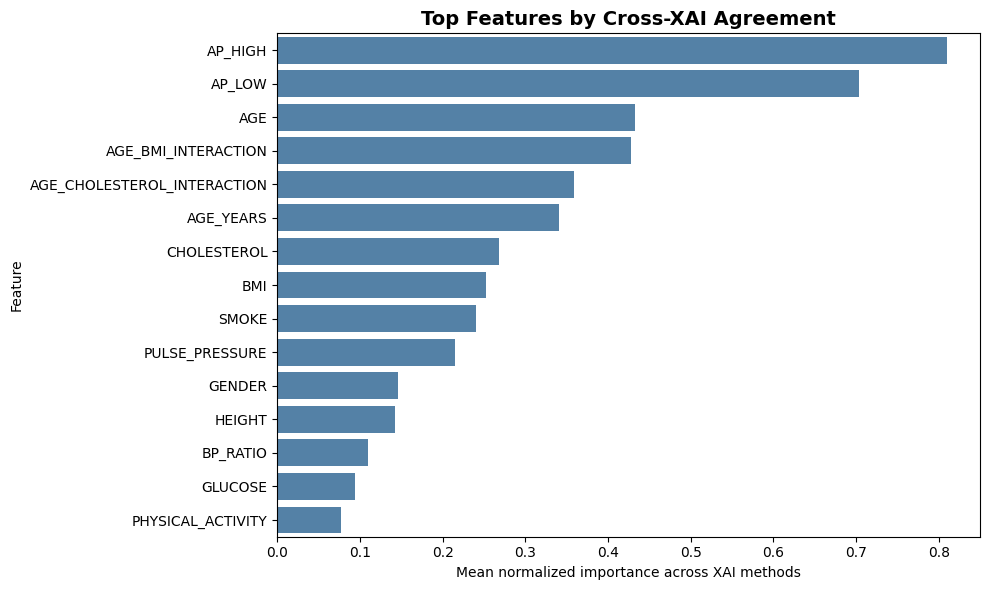

In [30]:
xai_rank_tables = []

if len(shap_importance_df) > 0:
    tmp = shap_importance_df.copy()
    tmp["method"] = "SHAP"
    tmp["score"] = tmp["mean_abs_shap"]
    xai_rank_tables.append(tmp[["feature", "method", "score"]])

tmp = ig_importance_df.copy()
tmp["method"] = "Integrated Gradients"
tmp["score"] = tmp["mean_abs_integrated_gradient"]
xai_rank_tables.append(tmp[["feature", "method", "score"]])

tmp = gxi_importance_df.copy()
tmp["method"] = "Gradient x Input"
tmp["score"] = tmp["mean_abs_gradient_x_input"]
xai_rank_tables.append(tmp[["feature", "method", "score"]])

tmp = occlusion_df.copy()
tmp["method"] = "Occlusion"
tmp["score"] = tmp["mean_abs_probability_change"]
xai_rank_tables.append(tmp[["feature", "method", "score"]])

tmp = feature_acquisition_df.copy()
tmp["method"] = "Policy Acquisition Frequency"
tmp["score"] = tmp["overall_count"]
xai_rank_tables.append(tmp[["feature", "method", "score"]])

xai_long_df = pd.concat(xai_rank_tables, ignore_index=True)

xai_long_df["normalized_score"] = xai_long_df.groupby("method")["score"].transform(
    lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
)

xai_pivot = xai_long_df.pivot_table(
    index="feature",
    columns="method",
    values="normalized_score",
    aggfunc="mean",
).fillna(0)

xai_pivot["mean_xai_agreement_score"] = xai_pivot.mean(axis=1)
xai_pivot = xai_pivot.sort_values("mean_xai_agreement_score", ascending=False)

display(xai_pivot)
xai_pivot.to_csv(OUTPUT_DIR / "xai_comparative_method_agreement.csv")

plt.figure(figsize=(12, max(6, 0.35 * len(xai_pivot))))
sns.heatmap(xai_pivot.drop(columns=["mean_xai_agreement_score"]), cmap="viridis", linewidths=0.3)
plt.title("Comparative XAI Agreement Across RL Explanation Methods", fontsize=14, weight="bold")
plt.xlabel("XAI method")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "26_comparative_xai_agreement_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
top_agreement = xai_pivot.reset_index().head(15)
sns.barplot(data=top_agreement, x="mean_xai_agreement_score", y="feature", color="steelblue")
plt.title("Top Features by Cross-XAI Agreement", fontsize=14, weight="bold")
plt.xlabel("Mean normalized importance across XAI methods")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "27_top_features_cross_xai_agreement.png", dpi=220, bbox_inches="tight")
plt.show()

## 28. Clinical interpretation summary generated from the run

In [31]:
top_acquired = feature_acquisition_df.head(5)["feature"].tolist()
top_xai_agreement = xai_pivot.reset_index().head(5)["feature"].tolist()
mean_features = rl_test_metrics["mean_features_used"]
recall_value = rl_test_metrics["recall"]
f1_value = rl_test_metrics["f1"]

interpretation_summary = {
    "paper_implemented": "Glanois et al. (2024) - A Survey on Interpretable Reinforcement Learning",
    "implementation_type": "Interpretable clinical feature-acquisition DQN",
    "dataset_path": DATA_PATH,
    "target_column": TARGET_COLUMN_CLEAN,
    "rl_features": feature_names_rl,
    "dqn_test_metrics": {k: float(v) for k, v in rl_test_metrics.items()},
    "top_features_by_policy_acquisition": top_acquired,
    "top_features_by_cross_xai_agreement": top_xai_agreement,
    "distillation_fidelity": float(distillation_fidelity),
    "main_explanation_message": (
        "The RL policy is interpretable because it exposes the sequence of clinical features requested before diagnosis. "
        "Post-hoc XAI methods then quantify which observed features most strongly affect the CVD action value and probability."
    ),
    "clinical_note": (
        "This model is a research prototype and should not be used for autonomous clinical decisions. "
        "The asymmetric reward design intentionally prioritizes reducing false negatives, but this can increase false positives."
    ),
}

with open(OUTPUT_DIR / "glanois_rl_interpretation_summary.json", "w", encoding="utf-8") as f:
    json.dump(interpretation_summary, f, indent=4, default=str)

print("=" * 100)
print("RUN-GENERATED INTERPRETATION SUMMARY")
print("=" * 100)
print(f"Mean features acquired before diagnosis: {mean_features:.2f}")
print(f"Test F1: {f1_value:.4f}")
print(f"Test Recall: {recall_value:.4f}")
print(f"Policy distillation fidelity: {distillation_fidelity:.4f}")
print(f"Top acquired features: {top_acquired}")
print(f"Top cross-XAI agreement features: {top_xai_agreement}")
print("\nClinical interpretation:")
print(
    "The policy does not simply output a label. It first selects a small number of patient features, "
    "then performs a diagnosis. This produces a decision path that can be audited patient-by-patient. "
    "The strongest features are those repeatedly selected by the agent and consistently ranked by SHAP, "
    "Integrated Gradients, Gradient × Input, Occlusion, and acquisition frequency."
)

RUN-GENERATED INTERPRETATION SUMMARY
Mean features acquired before diagnosis: 5.31
Test F1: 0.7089
Test Recall: 0.8021
Policy distillation fidelity: 0.4673
Top acquired features: ['AGE', 'AGE_YEARS', 'AP_HIGH', 'PULSE_PRESSURE', 'ALCOHOL']
Top cross-XAI agreement features: ['AP_HIGH', 'AP_LOW', 'AGE', 'AGE_BMI_INTERACTION', 'AGE_CHOLESTEROL_INTERACTION']

Clinical interpretation:
The policy does not simply output a label. It first selects a small number of patient features, then performs a diagnosis. This produces a decision path that can be audited patient-by-patient. The strongest features are those repeatedly selected by the agent and consistently ranked by SHAP, Integrated Gradients, Gradient × Input, Occlusion, and acquisition frequency.


## 29. Save model artifacts

In [32]:
torch_model_path = OUTPUT_DIR / "glanois_2024_dqn_policy_state_dict.pt"
torch.save(policy_net.state_dict(), torch_model_path)

model_bundle = {
    "paper": "Glanois et al. (2024) - A Survey on Interpretable Reinforcement Learning",
    "data_path": DATA_PATH,
    "target_column": TARGET_COLUMN_CLEAN,
    "preprocessor": preprocessor,
    "selector_model": selector_model,
    "selected_indices": selected_indices,
    "processed_feature_names": processed_feature_names,
    "feature_names_rl": feature_names_rl,
    "class_names": class_names,
    "rl_hyperparameters": {
        "DQN_EPISODES": DQN_EPISODES,
        "MAX_STEPS": MAX_STEPS,
        "GAMMA": GAMMA,
        "LEARNING_RATE": LEARNING_RATE,
        "FEATURE_COST": FEATURE_COST,
        "REWARD_TRUE_POSITIVE": REWARD_TRUE_POSITIVE,
        "REWARD_TRUE_NEGATIVE": REWARD_TRUE_NEGATIVE,
        "REWARD_FALSE_POSITIVE": REWARD_FALSE_POSITIVE,
        "REWARD_FALSE_NEGATIVE": REWARD_FALSE_NEGATIVE,
    },
    "rl_test_metrics": rl_test_metrics,
    "baseline_results": baseline_results,
    "distilled_tree": distilled_tree,
    "distillation_fidelity": distillation_fidelity,
    "torch_state_dict_file": str(torch_model_path),
    "xai_methods": [
        "Feature acquisition frequency",
        "Patient-level decision trajectories",
        "Reward decomposition",
        "Action heatmap",
        "Policy distillation tree",
        "SHAP",
        "LIME",
        "Integrated Gradients",
        "Gradient x Input",
        "Occlusion sensitivity",
        "Counterfactual interventions",
        "Policy sensitivity curves",
        "Cross-XAI agreement",
    ],
}

joblib_path = OUTPUT_DIR / "glanois_2024_interpretable_rl_bundle.joblib"
joblib.dump(model_bundle, joblib_path)

print(f"Saved PyTorch DQN state dict to: {torch_model_path}")
print(f"Saved model bundle to: {joblib_path}")
print(f"All outputs saved under: {OUTPUT_DIR.resolve()}")

Saved PyTorch DQN state dict to: glanois_2024_interpretable_rl_outputs/glanois_2024_dqn_policy_state_dict.pt
Saved model bundle to: glanois_2024_interpretable_rl_outputs/glanois_2024_interpretable_rl_bundle.joblib
All outputs saved under: /kaggle/working/glanois_2024_interpretable_rl_outputs


This implementation follows the spirit of Glanois et al. by emphasizing both **intrinsic interpretability** and **post-hoc explainability**:

- **Intrinsic interpretability:** the feature-acquisition policy exposes which features were requested before diagnosis.
- **Reward interpretability:** the reward decomposition explains why the agent prefers recall-sensitive decisions.
- **Decision-making interpretability:** policy distillation converts the DQN behavior into a transparent decision tree.
- **Post-hoc explainability:** SHAP, LIME, Integrated Gradients, Gradient × Input, Occlusion, and Counterfactuals explain local/global decisions.
